<a href="https://colab.research.google.com/github/PatandyaW/Skripsikkk/blob/main/Skripsik2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
net_df = pd.read_csv('/content/drive/My Drive/dataskripshit/netflix_titles.csv')
net_df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2415,s2416,TV Show,Queen of the South,NaN,"Alice Braga, Veronica Falcón, Justina Machado,...","United States, Mexico, Spain, Malta","June 6, 2020",2018,TV-MA,4 Seasons,"Crime TV Shows, TV Action & Adventure, TV Dramas",Forced to work for a cartel that recently kill...
6393,s6394,TV Show,Burnistoun,NaN,"Iain Connell, Robert Florence, Kirsty Strain, ...",United Kingdom,"October 1, 2019",2012,TV-MA,2 Seasons,"British TV Shows, TV Comedies",This sketch series focuses on the eccentric ch...
6249,s6250,TV Show,Bat Pat,NaN,"Rosa Romay, Alberto Escobal, Jaime de Diego, J...",Italy,"December 31, 2017",2016,TV-Y,1 Season,Kids' TV,A curious and talkative bat finds spooky fun o...
3032,s3033,Movie,Made in China,Mikhil Musale,"Rajkummar Rao, Boman Irani, Mouni Roy, Sumeet ...",India,"January 12, 2020",2019,TV-MA,128 min,"Comedies, Dramas, International Movies","After a trip to China, a struggling entreprene..."
6839,s6840,Movie,Get Him to the Greek,Nicholas Stoller,"Jonah Hill, Russell Brand, Elisabeth Moss, Ros...",United States,"January 16, 2020",2010,R,109 min,"Comedies, Music & Musicals",Ambitious young record company intern Aaron mu...


In [4]:
net_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
net_df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [6]:
missing_country = net_df[net_df['country'].isna()]
print(f"Jumlah baris dengan country kosong: {len(missing_country)}")
missing_country[['title', 'country']]

Jumlah baris dengan country kosong: 831


,title,country
2,Ganglands,NaN
3,Jailbirds New Orleans,NaN
5,Midnight Mass,NaN
6,My Little Pony: A New Generation,NaN
10,"Vendetta: Truth, Lies and The Mafia",NaN
...,...,...
8718,Westside vs. the World,NaN
8759,World's Weirdest Homes,NaN
8783,Yoko,NaN
8785,YOM,NaN


In [7]:
net_df[net_df.director.isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada","May 1, 2018",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


In [8]:
print("Jumlah duplikasi: ", net_df.duplicated().sum())

Jumlah duplikasi:  0


In [9]:
for i in net_df.columns:
    null_rate = net_df[i].isna().sum() / len(net_df) * 100
    if null_rate > 0 :
        print("{} null rate: {}%".format(i,round(null_rate,2)))

director null rate: 29.91%
cast null rate: 9.37%
country null rate: 9.44%
date_added null rate: 0.11%
rating null rate: 0.05%
duration null rate: 0.03%


In [10]:
# net_df.describe(include="all")

In [11]:
net_df['country'] = net_df['country'].fillna(net_df['country'].mode()[0])
net_df['cast'].replace(np.nan, 'No Data',inplace  = True)
net_df['director'].replace(np.nan, 'No Data',inplace  = True)


net_df.dropna(inplace=True)
net_df.drop_duplicates(inplace= True)

<ipython-input-11-558a2bed9fc2>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  net_df['cast'].replace(np.nan, 'No Data',inplace  = True)
<ipython-input-11-558a2bed9fc2>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [12]:
net_df["date_added"] = net_df["date_added"].str.strip()

net_df["date_added"] = pd.to_datetime(net_df['date_added'])

net_df['month_added']=net_df['date_added'].dt.month
net_df['month_name_added']=net_df['date_added'].dt.month_name()
net_df['year_added'] = net_df['date_added'].dt.year
net_df['day_name_added'] = net_df['date_added'].dt.day_name()


In [13]:
time = net_df["year_added"] - net_df["release_year"]

# simpan data di kolom baru 'time' (ini tahun)
net_df["time"] = time
net_df.head(15)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added,day_name_added,time
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,September,2021,Saturday,1
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,September,2021,Friday,0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9,September,2021,Friday,0
3,s4,TV Show,Jailbirds New Orleans,No Data,No Data,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9,September,2021,Friday,0
4,s5,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9,September,2021,Friday,0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,9,September,2021,Friday,0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,9,September,2021,Friday,0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",9,September,2021,Friday,28
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,9,September,2021,Friday,0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,9,September,2021,Friday,0


In [14]:
net_df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added,day_name_added,time
count,8790,8790,8790,8790,8790,8790,8790,8790.000000,8790,8790,8790,8790,8790.000000,8790,8790.000000,8790,8790.000000
unique,8790,2,8790,4527,7679,748,NaN,NaN,14,220,513,8758,NaN,12,NaN,7,NaN
top,s8807,Movie,Zubaan,No Data,No Data,United States,NaN,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",NaN,July,NaN,Friday,NaN
freq,1,6126,1,2621,825,3638,NaN,NaN,3205,1791,362,4,NaN,827,NaN,2497,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-17 21:44:01.638225408,2014.183163,NaN,NaN,NaN,NaN,6.655859,NaN,2018.873606,NaN,4.690444
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN,1.000000,NaN,2008.000000,NaN,-3.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-06 00:00:00,2013.000000,NaN,NaN,NaN,NaN,4.000000,NaN,2018.000000,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-03 00:00:00,2017.000000,NaN,NaN,NaN,NaN,7.000000,NaN,2019.000000,NaN,1.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-19 18:00:00,2019.000000,NaN,NaN,NaN,NaN,10.000000,NaN,2020.000000,NaN,5.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,NaN,12.000000,NaN,2021.000000,NaN,93.000000


Berdasarkan hasil tersebut, dapat diketahui bahwa rata-rata waktu rilis konten film/acara tv terlampau selama 4 tahun dengan nilai tahun maksimum sebesar 93 tahun.

In [15]:
# Calculate time difference in years for movies
net_df.loc[net_df['type'] == 'Movie', 'time2'] = net_df['year_added'] - net_df['release_year']

# Calculate time difference in years for TV shows
net_df.loc[net_df['type'] == 'TV Show', 'time3'] = net_df['year_added'] - net_df['release_year']

# Display the first 15 rows to verify
net_df.describe(include="all")


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added,day_name_added,time,time2,time3
count,8790,8790,8790,8790,8790,8790,8790,8790.000000,8790,8790,8790,8790,8790.000000,8790,8790.000000,8790,8790.000000,6126.000000,2664.000000
unique,8790,2,8790,4527,7679,748,NaN,NaN,14,220,513,8758,NaN,12,NaN,7,NaN,NaN,NaN
top,s8807,Movie,Zubaan,No Data,No Data,United States,NaN,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",NaN,July,NaN,Friday,NaN,NaN,NaN
freq,1,6126,1,2621,825,3638,NaN,NaN,3205,1791,362,4,NaN,827,NaN,2497,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-17 21:44:01.638225408,2014.183163,NaN,NaN,NaN,NaN,6.655859,NaN,2018.873606,NaN,4.690444,5.730983,2.297673
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN,1.000000,NaN,2008.000000,NaN,-3.000000,-1.000000,-3.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-06 00:00:00,2013.000000,NaN,NaN,NaN,NaN,4.000000,NaN,2018.000000,NaN,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-03 00:00:00,2017.000000,NaN,NaN,NaN,NaN,7.000000,NaN,2019.000000,NaN,1.000000,2.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-19 18:00:00,2019.000000,NaN,NaN,NaN,NaN,10.000000,NaN,2020.000000,NaN,5.000000,7.000000,2.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,NaN,12.000000,NaN,2021.000000,NaN,93.000000,75.000000,93.000000


**Film**

Berdasarkan hasil tersebut, dapat diketahui bahwa rata-rata waktu rilis konten film terlampau selama 5.730983 tahun dengan nilai tahun maksimum sebesar 75 tahun.

**Acara TV**

Sedangkan kita dapat diketahui bahwa rata-rata waktu rilis konten acara tv terlampau selama 2.297673 tahun dengan nilai tahun maksimum sebesar 93 tahun.

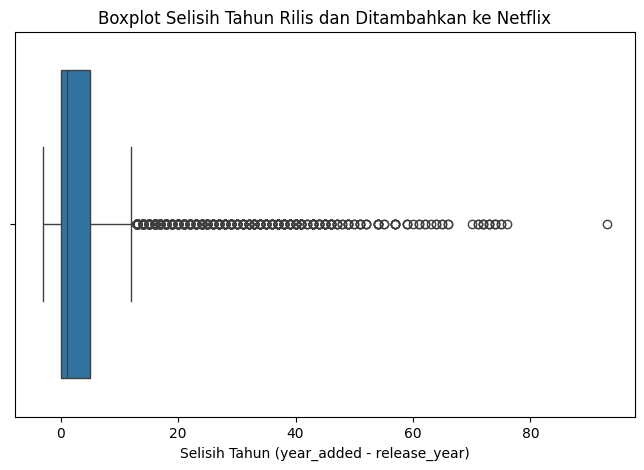

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(x=net_df["time"])
plt.title("Boxplot Selisih Tahun Rilis dan Ditambahkan ke Netflix")
plt.xlabel("Selisih Tahun (year_added - release_year)")
plt.show()


In [17]:
# Sebelum membersihkan outlier
before = len(net_df)

# 2. Menghitung IQR
Q1 = net_df['time'].quantile(0.25)
Q3 = net_df['time'].quantile(0.75)
IQR = Q3 - Q1

# 3. Menentukan batas outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Simpan data outlier ke variabel terpisah
outliers_df = net_df[(net_df['time'] < lower_bound) | (net_df['time'] > upper_bound)]

# 5. Simpan data bersih
net_df_cleaned = net_df[(net_df['time'] >= lower_bound) & (net_df['time'] <= upper_bound)]

# 6. Statistik
after = len(net_df_cleaned)

print(f"Jumlah data sebelum dibersihkan: {before}")
print(f"Jumlah data setelah dibersihkan: {after}")
print(f"Jumlah data yang dianggap outlier: {before - after}")


Jumlah data sebelum dibersihkan: 8790
Jumlah data setelah dibersihkan: 7818
Jumlah data yang dianggap outlier: 972


In [18]:
df_negatif = net_df[net_df['time'] < 0]
print(df_negatif[['title', 'release_year', 'year_added', 'time']])
print(f"Jumlah data dengan selisih tahun negatif: {len(df_negatif)}")
net_df = net_df[net_df['time'] >= 0]

                           title  release_year  year_added  time
1551                       Hilda          2021        2020    -1
1696                Polly Pocket          2021        2020    -1
2920               Love Is Blind          2021        2020    -1
3168                Fuller House          2020        2019    -1
3287          Maradona in Mexico          2020        2019    -1
3369             BoJack Horseman          2020        2019    -1
3433            The Hook Up Plan          2020        2019    -1
4844   Unbreakable Kimmy Schmidt          2019        2018    -1
4845        Arrested Development          2019        2018    -1
5394  Hans Teeuwen: Real Rancour          2018        2017    -1
5658                      Sense8          2018        2016    -2
5677                 Tokyo Trial          2017        2016    -1
7063                    Incoming          2019        2018    -1
7112                 Jack Taylor          2016        2013    -3
Jumlah data dengan selisi

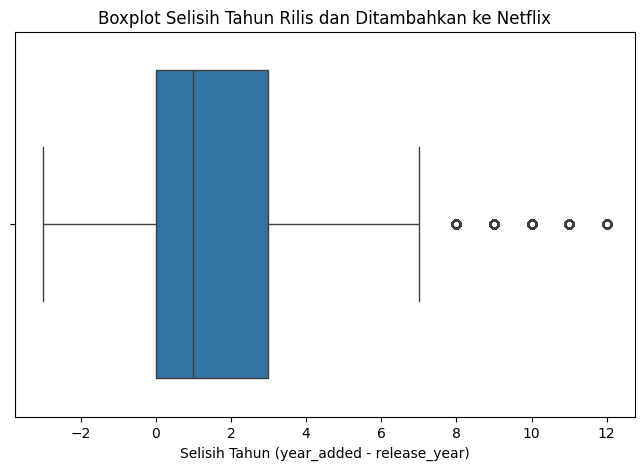

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(x=net_df_cleaned["time"])
plt.title("Boxplot Selisih Tahun Rilis dan Ditambahkan ke Netflix")
plt.xlabel("Selisih Tahun (year_added - release_year)")
plt.show()


<ipython-input-20-138bcba42abc>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='viridis')


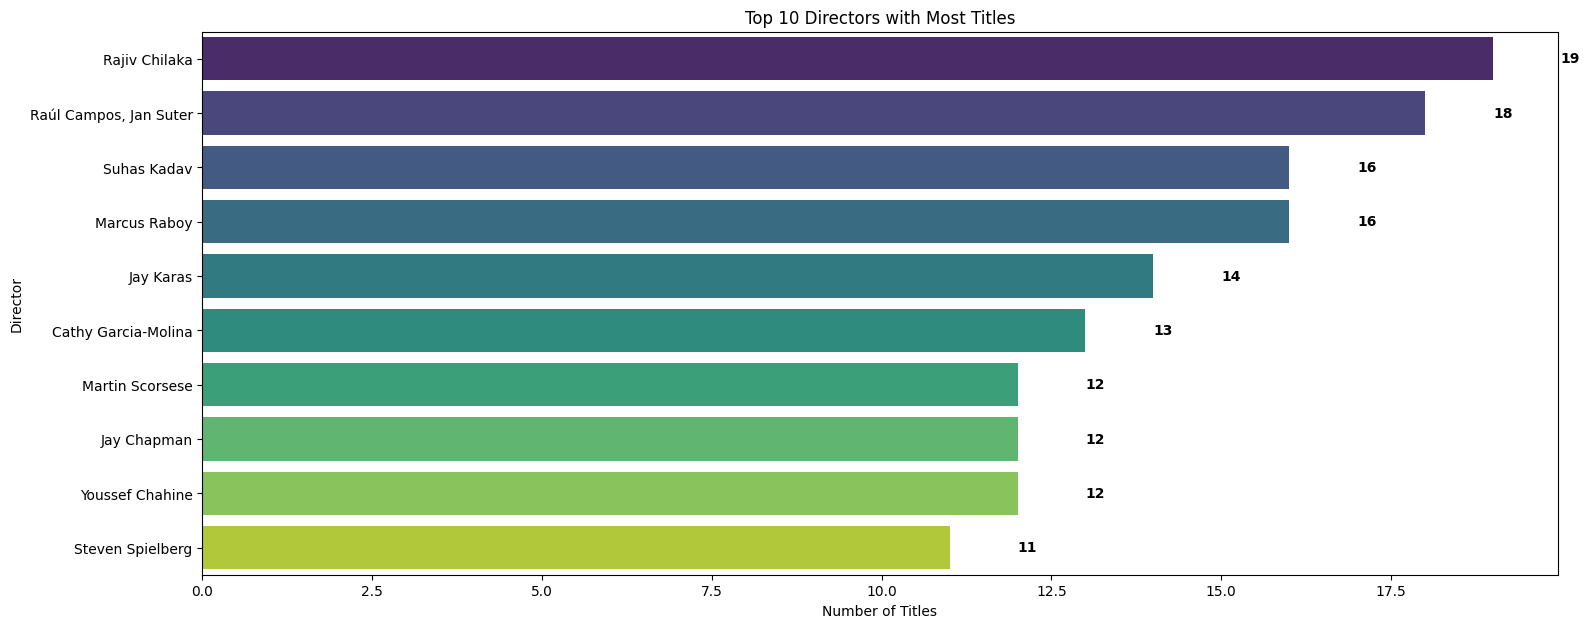

In [20]:
# Top 10 directors
filtered_directors = net_df[net_df['director'] != 'No Data']

# Hitung top 10 direktur terbanyak
top_directors = filtered_directors['director'].value_counts().head(10)
plt.figure(figsize=(16, 24))
plt.subplot(4, 1, 1)
sns.barplot(x=top_directors.values, y=top_directors.index, palette='viridis')
plt.title('Top 10 Directors with Most Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')

#nambahin
for i, v in enumerate(top_directors.values):
    plt.text(v + 1, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

<ipython-input-21-0e1e23e7bb20>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cast_df, x='count', y='cast', palette='viridis')


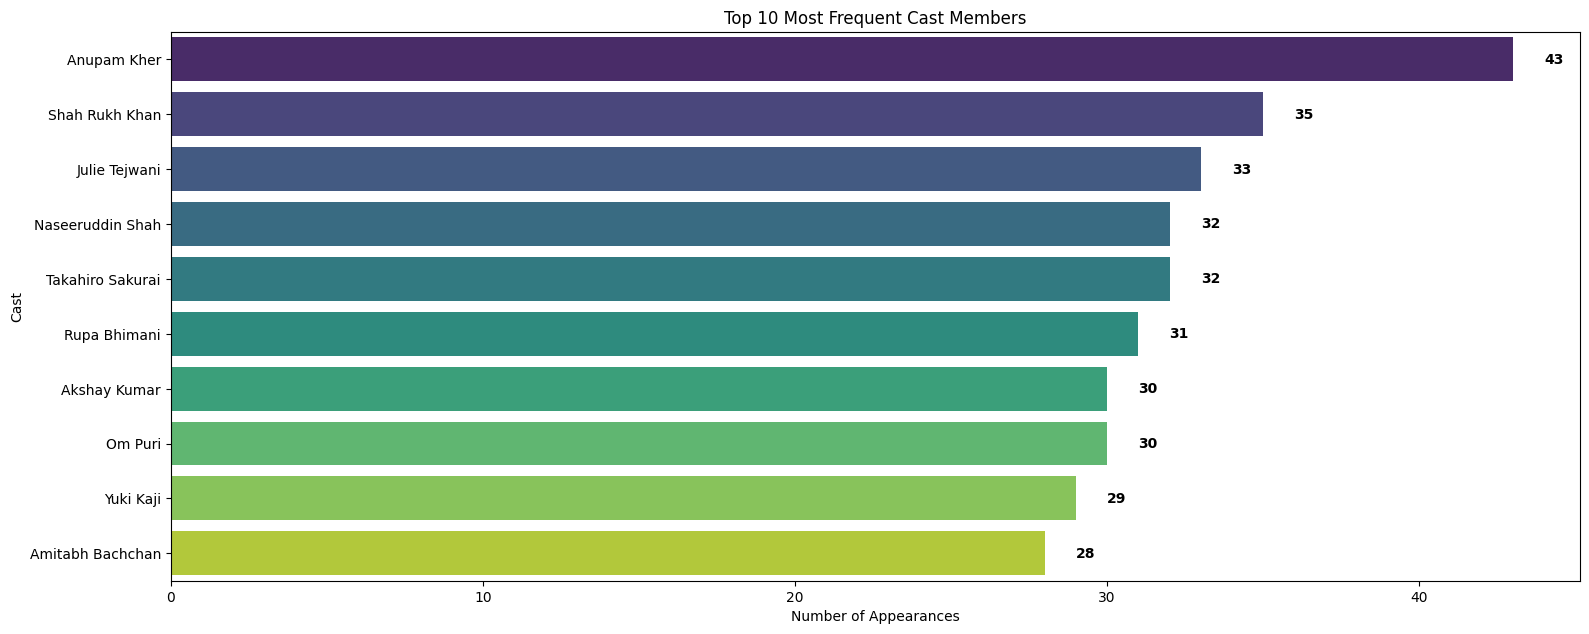

In [21]:
from collections import Counter

cast_list = net_df['cast'].str.split(', ')
flat_cast = [item for sublist in cast_list for item in sublist if item != 'No Data']
top_cast = Counter(flat_cast).most_common(10)
top_cast_df = pd.DataFrame(top_cast, columns=['cast', 'count'])
plt.figure(figsize=(16, 24))
plt.subplot(4, 1, 2)
sns.barplot(data=top_cast_df, x='count', y='cast', palette='viridis')
plt.title('Top 10 Most Frequent Cast Members')
plt.xlabel('Number of Appearances')
plt.ylabel('Cast')

for i, v in enumerate(top_cast_df['count']):
    plt.text(v + 1, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
movies_df = net_df[net_df['type'] == 'Movie'].copy()
tv_df = net_df[net_df['type'] == 'TV Show'].copy()

# Extract numeric duration for each with correct context
movies_df['duration_minutes'] = movies_df['duration'].str.extract('(\d+)').astype(float)
tv_df['duration_seasons'] = tv_df['duration'].str.extract('(\d+)').astype(float)

# Now you can get top 10 for each safely
top_movies = movies_df.sort_values(by='duration_minutes', ascending=False).head(10)
top_tv = tv_df.sort_values(by='duration_seasons', ascending=False).head(10)

<ipython-input-23-fbb054bc6a4e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='duration_seasons', y='title', data=top_tv, palette='crest')


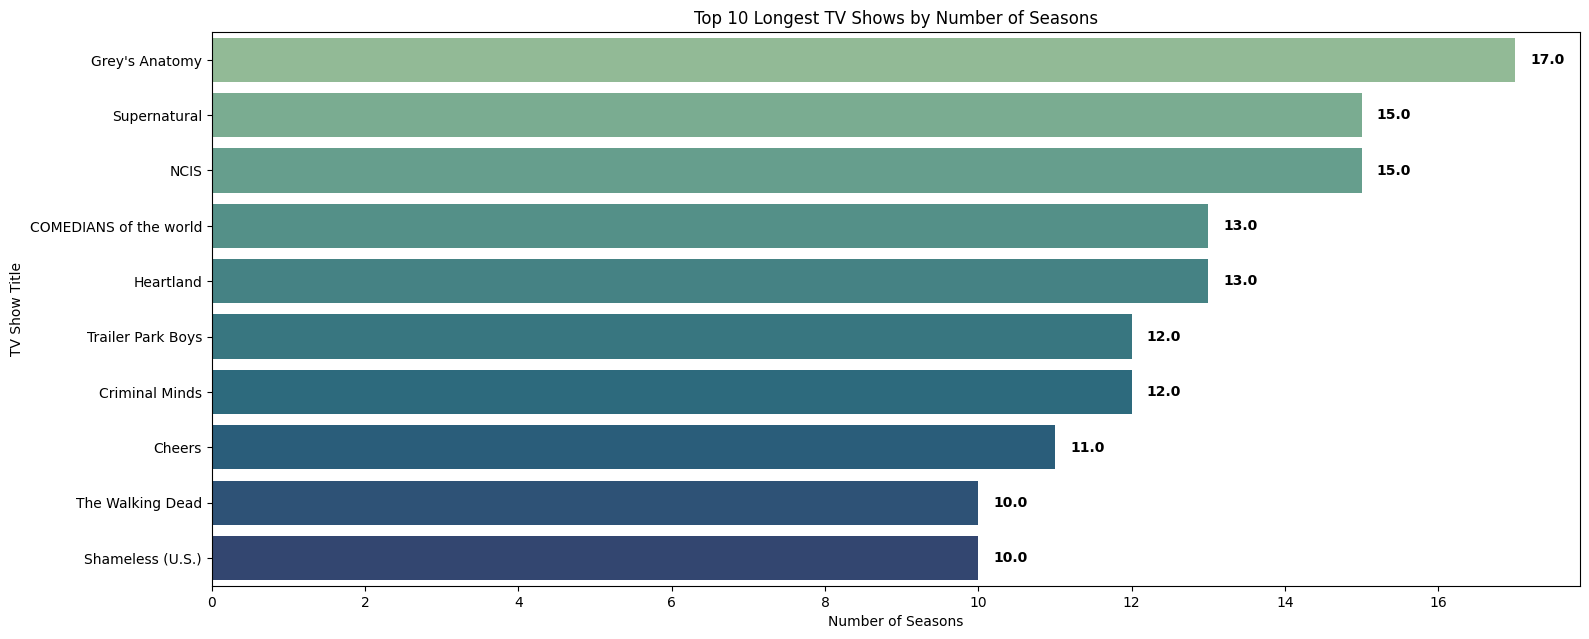

In [23]:
plt.figure(figsize=(16, 24))
plt.subplot(4, 1, 4)
sns.barplot(x='duration_seasons', y='title', data=top_tv, palette='crest')
plt.title('Top 10 Longest TV Shows by Number of Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('TV Show Title')

# Add value labels to bars
for i, (val, name) in enumerate(zip(top_tv['duration_seasons'], top_tv['title'])):
    plt.text(val + 0.2, i, str(val), va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

<ipython-input-24-0cd8f94413df>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='duration_minutes', y='title', data=top_movies, palette='crest')


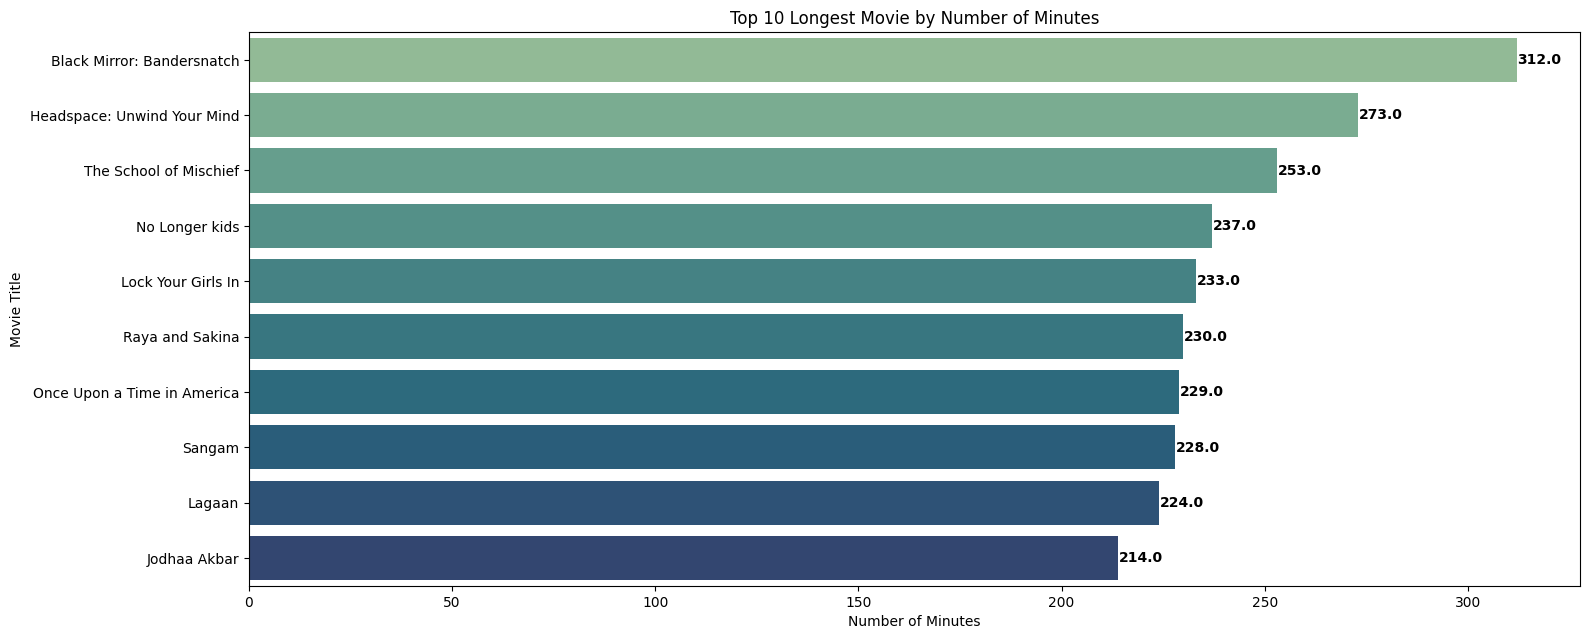

In [24]:
plt.figure(figsize=(16, 24))
plt.subplot(4, 1, 4)
sns.barplot(x='duration_minutes', y='title', data=top_movies, palette='crest')
plt.title('Top 10 Longest Movie by Number of Minutes')
plt.xlabel('Number of Minutes')
plt.ylabel('Movie Title')

# Add value labels to bars
for i, (val, name) in enumerate(zip(top_movies['duration_minutes'], top_movies['title'])):
    plt.text(val + 0.2, i, str(val), va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
tv_genres = net_df[net_df['type'] == 'TV Show']['listed_in'].dropna().str.split(', ')
movie_genres = net_df[net_df['type'] == 'Movie']['listed_in'].dropna().str.split(', ')

# Flatten list dan hitung frekuensi genre
tv_genre_counts = Counter([genre for sublist in tv_genres for genre in sublist])
movie_genre_counts = Counter([genre for sublist in movie_genres for genre in sublist])

# Ambil 10 genre teratas
top_tv_genres = pd.DataFrame(tv_genre_counts.most_common(10), columns=['Genre', 'Count'])
top_movie_genres = pd.DataFrame(movie_genre_counts.most_common(10), columns=['Genre', 'Count'])



<ipython-input-26-d655453e0ec2>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=top_tv_genres, palette='rocket')


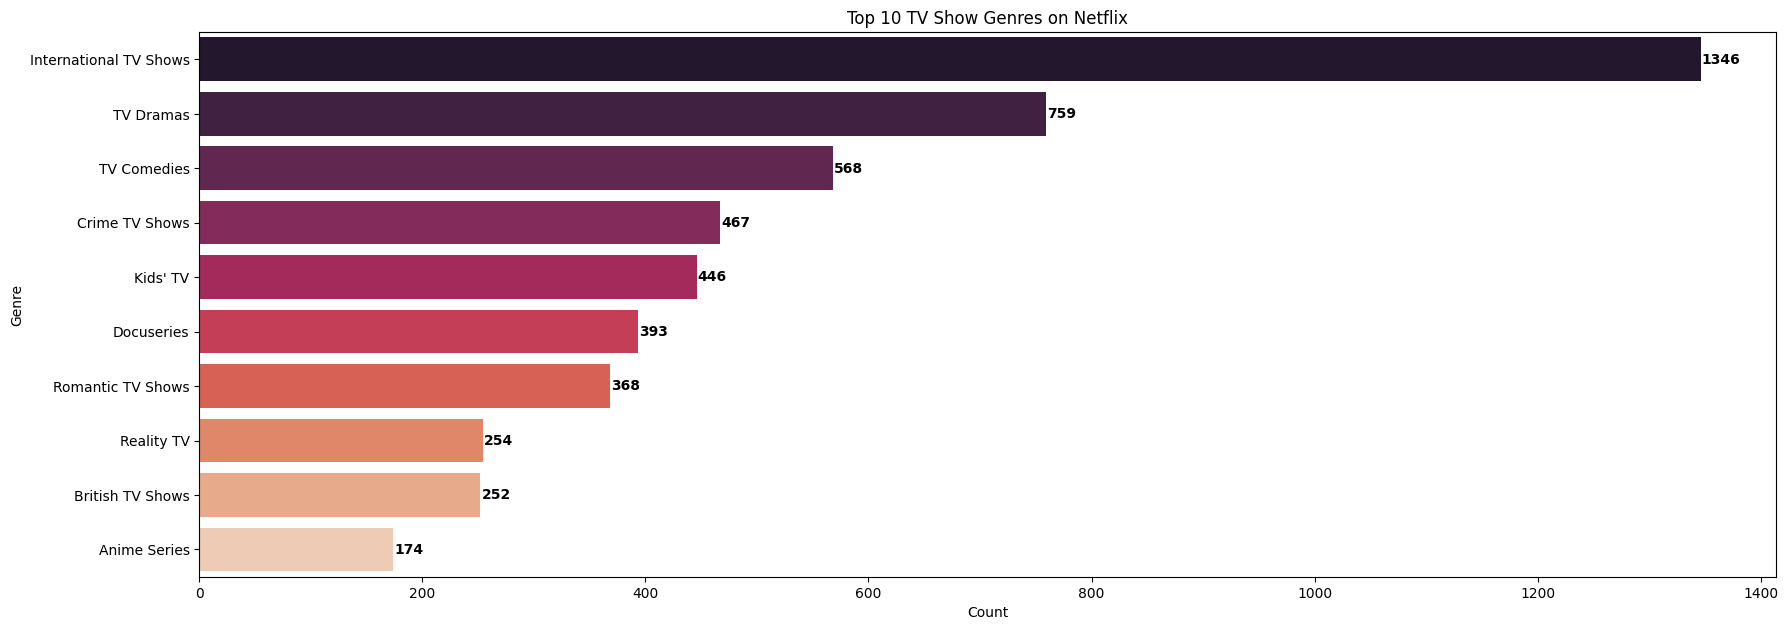

In [26]:
plt.figure(figsize=(18, 12))

# TV Genre
plt.subplot(2, 1, 1)
sns.barplot(x='Count', y='Genre', data=top_tv_genres, palette='rocket')
plt.title('Top 10 TV Show Genres on Netflix')
for i, (count, genre) in enumerate(zip(top_tv_genres['Count'], top_tv_genres['Genre'])):
    plt.text(count + 1, i, str(count), va='center', fontweight='bold', color='black')
plt.tight_layout()
plt.show()

<ipython-input-27-f9891717b4dc>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=top_movie_genres, palette='mako')


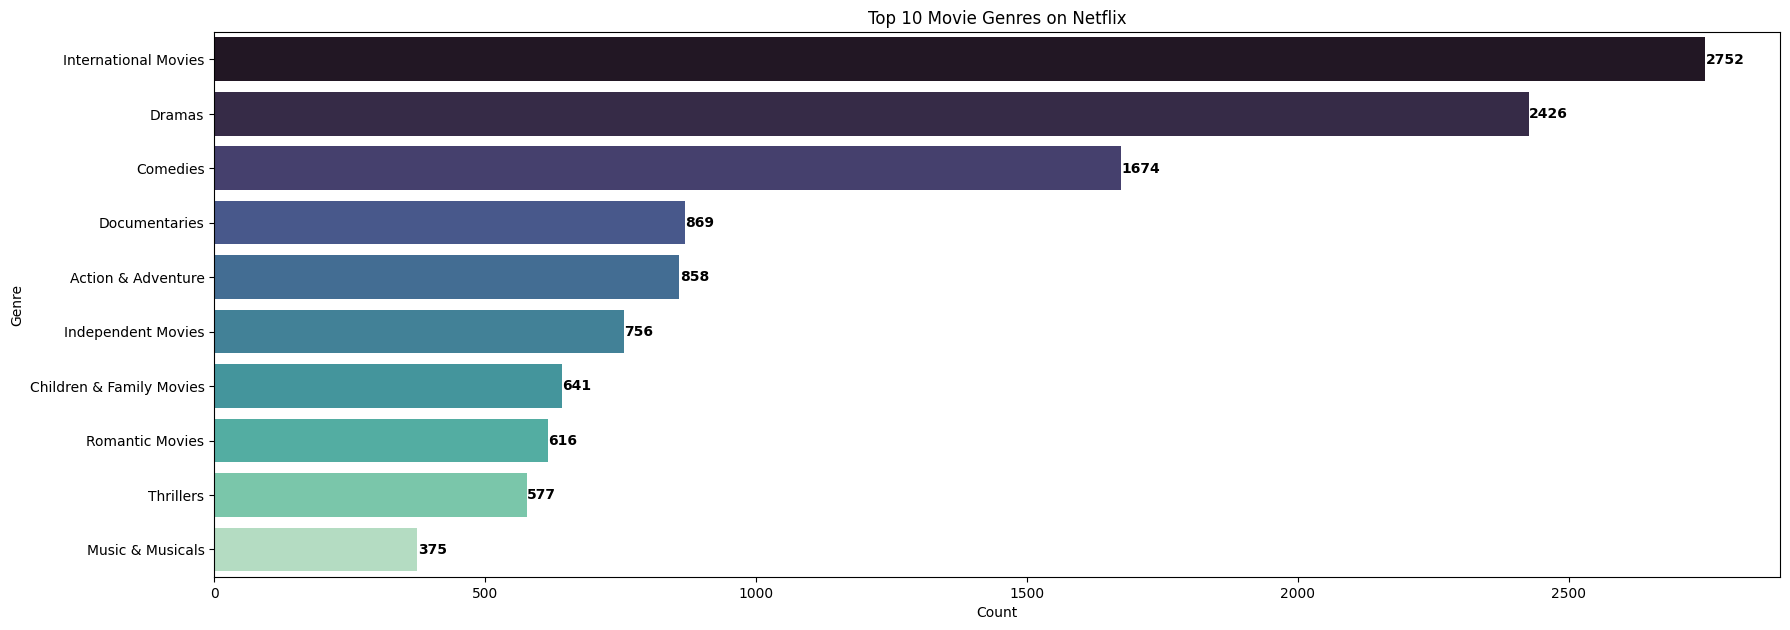

In [27]:
plt.figure(figsize=(18, 12))

plt.subplot(2, 1, 2)
sns.barplot(x='Count', y='Genre', data=top_movie_genres, palette='mako')
plt.title('Top 10 Movie Genres on Netflix')
for i, (count, genre) in enumerate(zip(top_movie_genres['Count'], top_movie_genres['Genre'])):
    plt.text(count + 1, i, str(count), va='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

In [28]:
def get_top_3_genres_each_year(df, content_type):
    rows = []
    for year in sorted(df['year_added'].dropna().unique()):
        year_df = df[df['year_added'] == year]
        genres = year_df['listed_in'].dropna().str.split(',')
        all_genres = [genre.strip() for sublist in genres for genre in sublist]
        genre_counts = pd.Series(all_genres).value_counts().head(3)
        if len(genre_counts) == 3:  # pastikan hanya ambil tahun dengan 3 genre teratas
            for genre, count in genre_counts.items():
                rows.append({'year_added': year, 'genre': genre, 'count': count, 'type': content_type})
    return pd.DataFrame(rows)

# Pisahkan berdasarkan type
movies = net_df[net_df['type'] == 'Movie']
tv_shows = net_df[net_df['type'] == 'TV Show']

# Dapatkan top genre per tahun untuk masing-masing
movie_genres = get_top_3_genres_each_year(movies, 'Movie')
tv_genres = get_top_3_genres_each_year(tv_shows, 'TV Show')

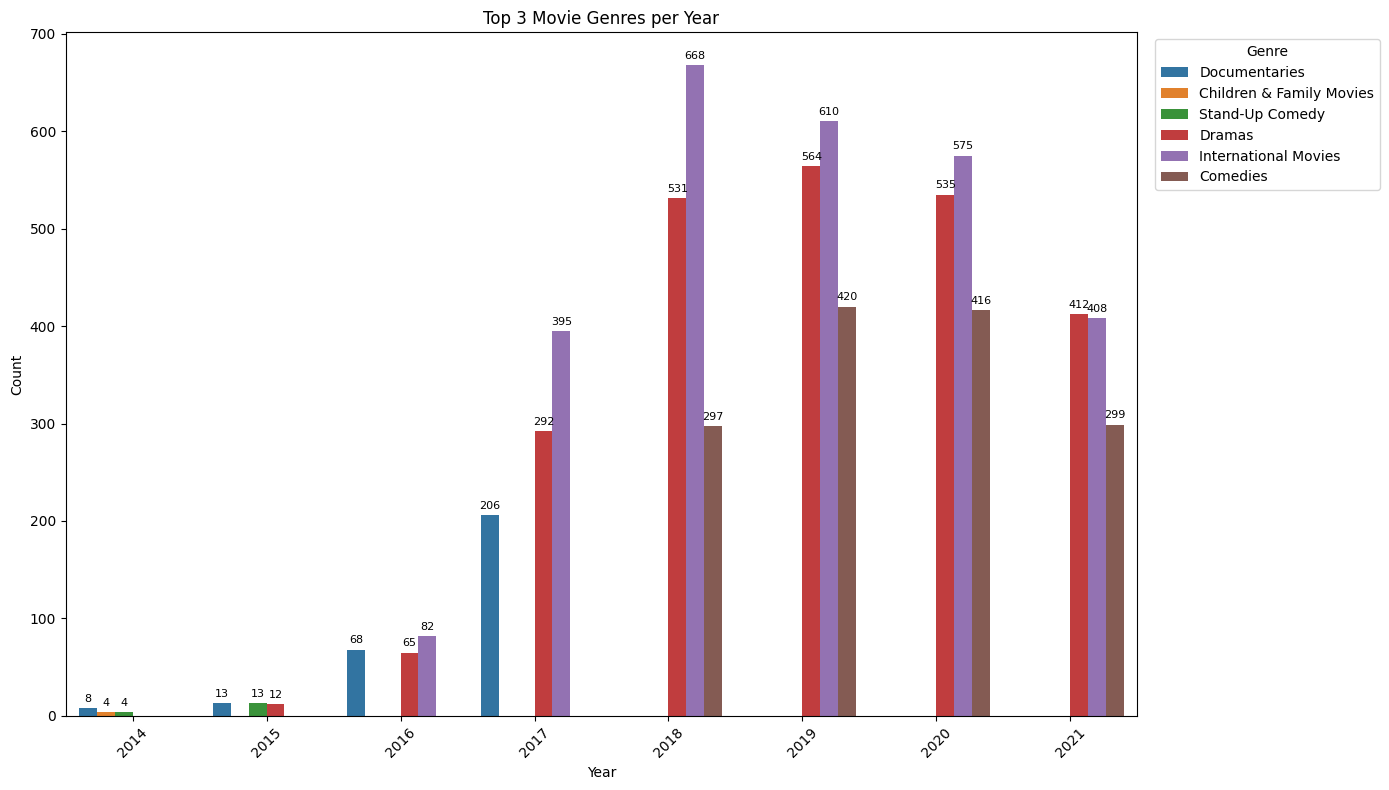

In [29]:
# Filter tahun 2014 ke atas
filtered_movie_genres = movie_genres[movie_genres['year_added'] >= 2014]

plt.figure(figsize=(14, 8))
ax = sns.barplot(data=filtered_movie_genres, x='year_added', y='count', hue='genre')

# Tambahkan angka di atas tiap bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=8, padding=3)

plt.title('Top 3 Movie Genres per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Genre', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


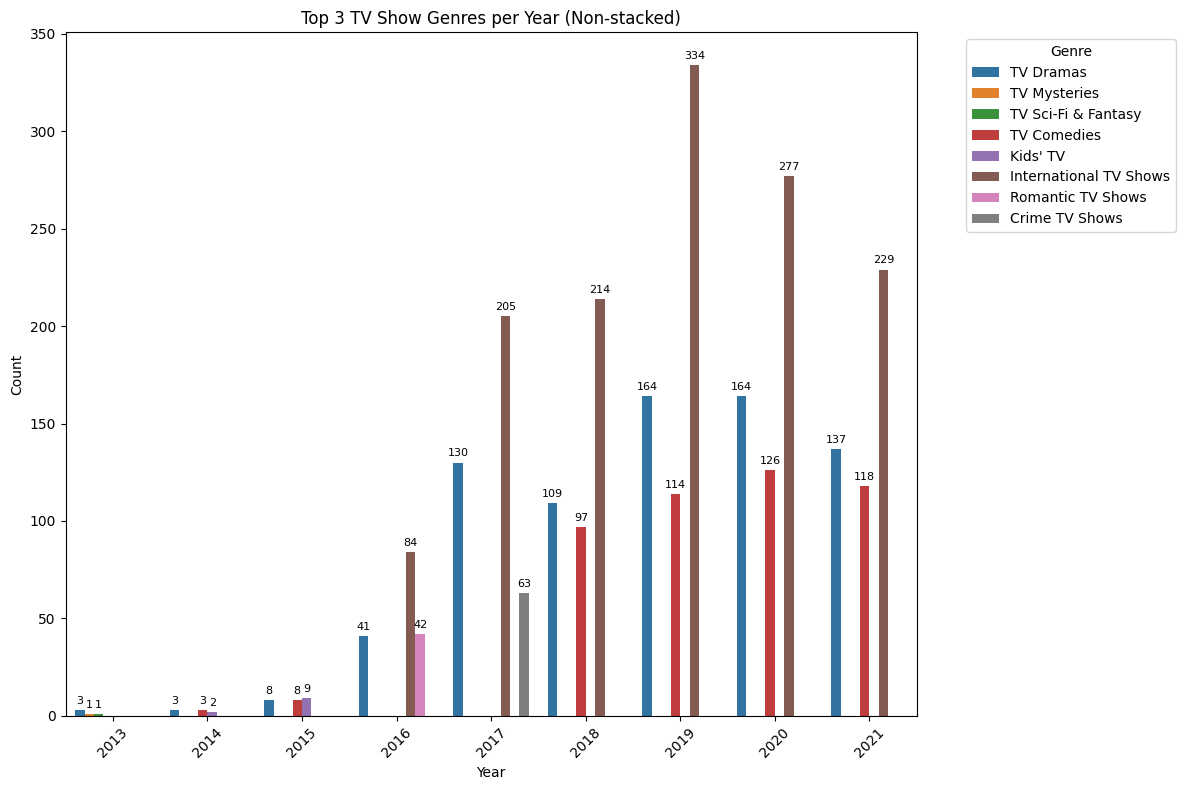

In [30]:
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=tv_genres, x='year_added', y='count', hue='genre')

# Tambahkan angka di atas tiap bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=8, padding=3)
plt.title('Top 3 TV Show Genres per Year (Non-stacked)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
net_df["listed_in"].unique()

array(['Documentaries', 'International TV Shows, TV Dramas, TV Mysteries',
       'Crime TV Shows, International TV Shows, TV Action & Adventure',
       'Docuseries, Reality TV',
       'International TV Shows, Romantic TV Shows, TV Comedies',
       'TV Dramas, TV Horror, TV Mysteries', 'Children & Family Movies',
       'Dramas, Independent Movies, International Movies',
       'British TV Shows, Reality TV', 'Comedies, Dramas',
       'Crime TV Shows, Docuseries, International TV Shows',
       'Dramas, International Movies',
       'Children & Family Movies, Comedies',
       'British TV Shows, Crime TV Shows, Docuseries',
       'TV Comedies, TV Dramas', 'Documentaries, International Movies',
       'Crime TV Shows, Spanish-Language TV Shows, TV Dramas',
       'Thrillers',
       'International TV Shows, Spanish-Language TV Shows, TV Action & Adventure',
       'International TV Shows, TV Action & Adventure, TV Dramas',
       'Comedies, International Movies',
       'Comedies, 

In [32]:
from collections import Counter

all_genres = [genre.strip() for sublist in net_df["listed_in"].str.split(',') for genre in sublist]
genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values(by='Count', ascending=False)

print(genre_df)


                           Genre  Count
14          International Movies   2752
12                        Dramas   2426
16                      Comedies   1674
1         International TV Shows   1346
0                  Documentaries    869
25            Action & Adventure    858
2                      TV Dramas    759
13            Independent Movies    756
11      Children & Family Movies    641
19               Romantic Movies    616
18                     Thrillers    577
9                    TV Comedies    568
4                 Crime TV Shows    467
24                      Kids' TV    446
6                     Docuseries    393
20              Music & Musicals    375
8              Romantic TV Shows    368
21                 Horror Movies    357
38               Stand-Up Comedy    342
7                     Reality TV    254
15              British TV Shows    252
22              Sci-Fi & Fantasy    242
29                 Sports Movies    219
30                  Anime Series    174


<ipython-input-33-ca6bce9c660a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_df.head(10), x='Count', y='Genre', palette='plasma')


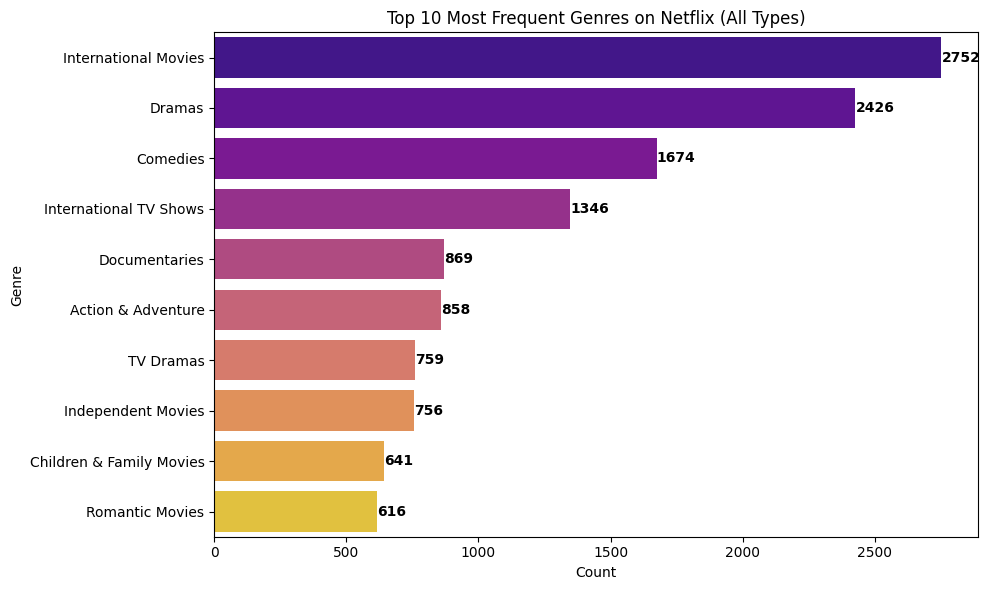

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(data=genre_df.head(10), x='Count', y='Genre', palette='plasma')
plt.title('Top 10 Most Frequent Genres on Netflix (All Types)')
for i, (count, genre) in enumerate(zip(genre_df['Count'].head(10), genre_df['Genre'].head(10))):
    plt.text(count + 1, i, str(count), va='center', fontweight='bold', color='black')
plt.tight_layout()
plt.show()

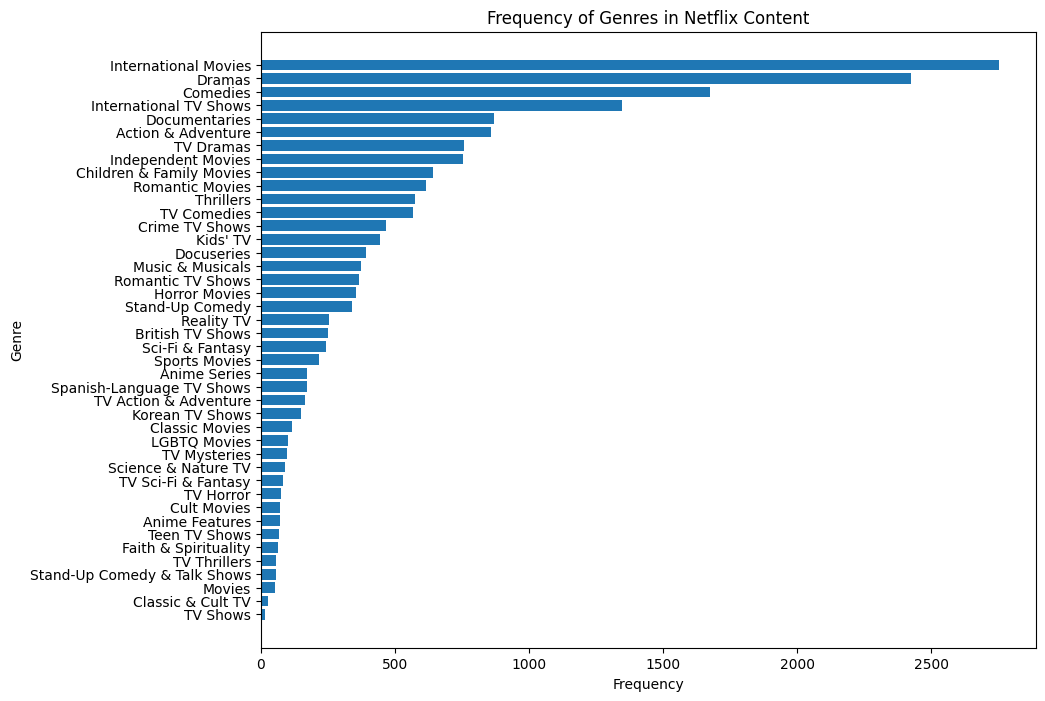

In [34]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 8))
plt.barh(genre_df['Genre'], genre_df['Count'])
plt.xlabel('Frequency')
plt.ylabel('Genre')
plt.title('Frequency of Genres in Netflix Content')
plt.gca().invert_yaxis()
plt.show()

In [35]:
def get_top_3_ratings_each_year(df, content_type):
    rows = []
    df = df[df['type'] == content_type]
    for year in sorted(df['year_added'].dropna().unique()):
        year_df = df[df['year_added'] == year]
        rating_counts = year_df['rating'].value_counts().head(3)
        if len(rating_counts) == 3:
            for rating, count in rating_counts.items():
                rows.append({
                    'year_added': year,
                    'rating': rating,
                    'count': count,
                    'type': content_type
                })
    return pd.DataFrame(rows)

top_ratings_movies = get_top_3_ratings_each_year(net_df, 'Movie')
top_ratings_tv = get_top_3_ratings_each_year(net_df, 'TV Show')


<ipython-input-36-e15a58c24147>:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=combined_top_ratings, x='year_added', y='count', hue='rating', ci=None)


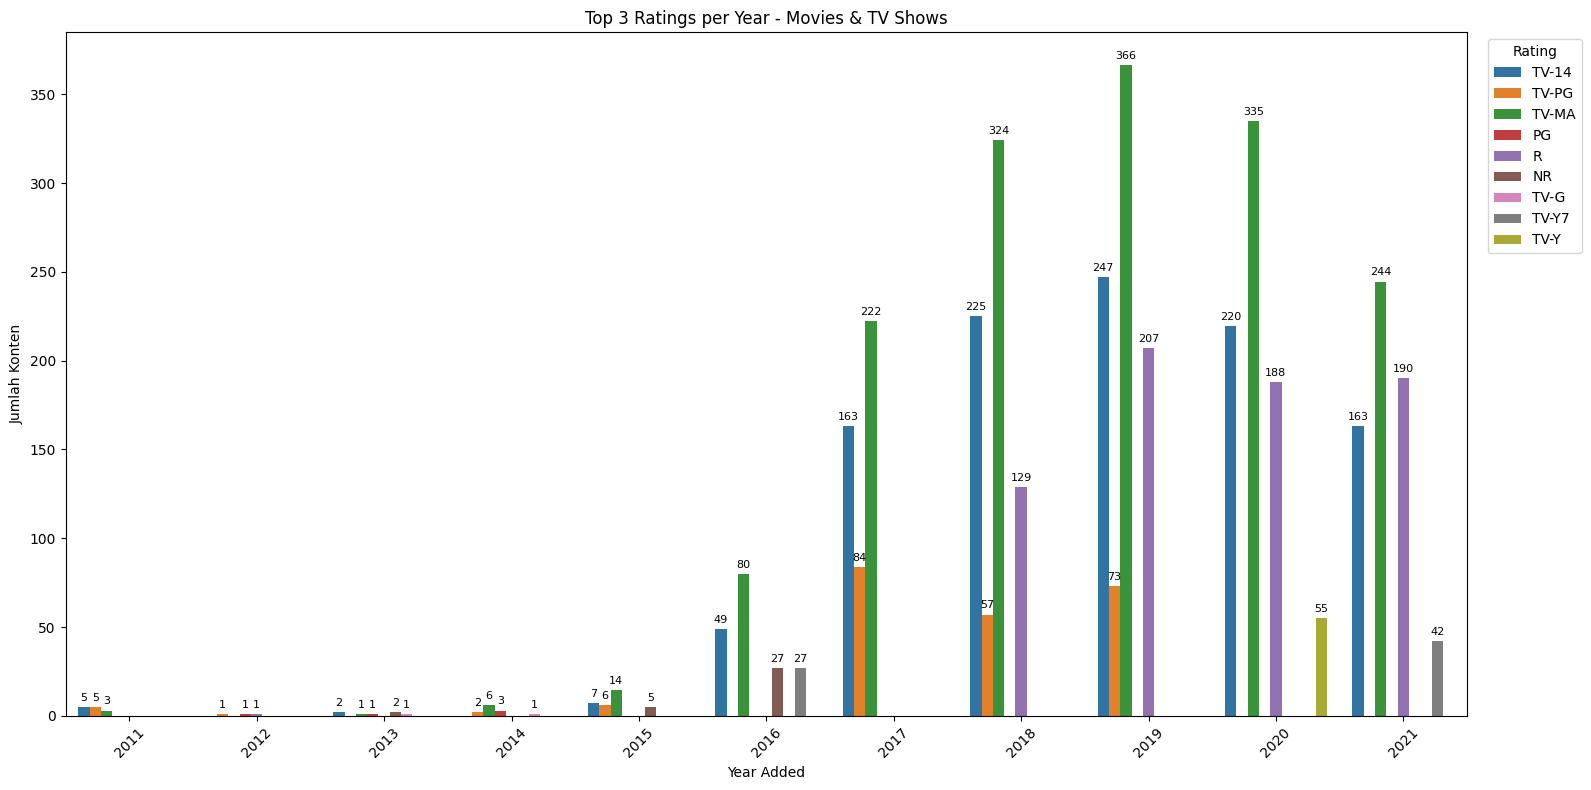

In [36]:
combined_top_ratings = pd.concat([top_ratings_movies, top_ratings_tv])

plt.figure(figsize=(16, 8))
ax = sns.barplot(data=combined_top_ratings, x='year_added', y='count', hue='rating', ci=None)

# Tambahkan label di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=8, padding=3)

plt.title('Top 3 Ratings per Year - Movies & TV Shows')
plt.xlabel('Year Added')
plt.ylabel('Jumlah Konten')
plt.xticks(rotation=45)
plt.legend(title='Rating', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

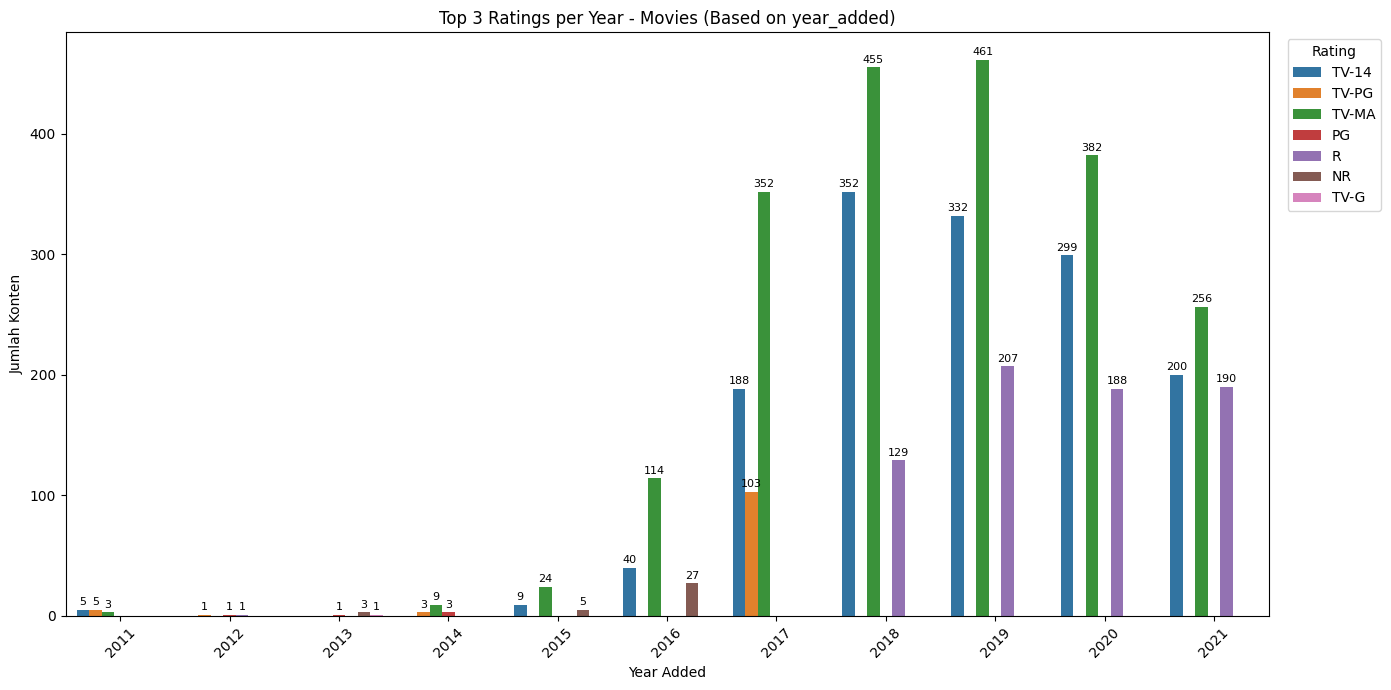

In [37]:
top_ratings_movies = get_top_3_ratings_each_year(net_df, 'Movie')
top_ratings_tv = get_top_3_ratings_each_year(net_df, 'TV Show')

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=top_ratings_movies, x='year_added', y='count', hue='rating')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=8, padding=2)

plt.title('Top 3 Ratings per Year - Movies (Based on year_added)')
plt.xlabel('Year Added')
plt.ylabel('Jumlah Konten')
plt.legend(title='Rating', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

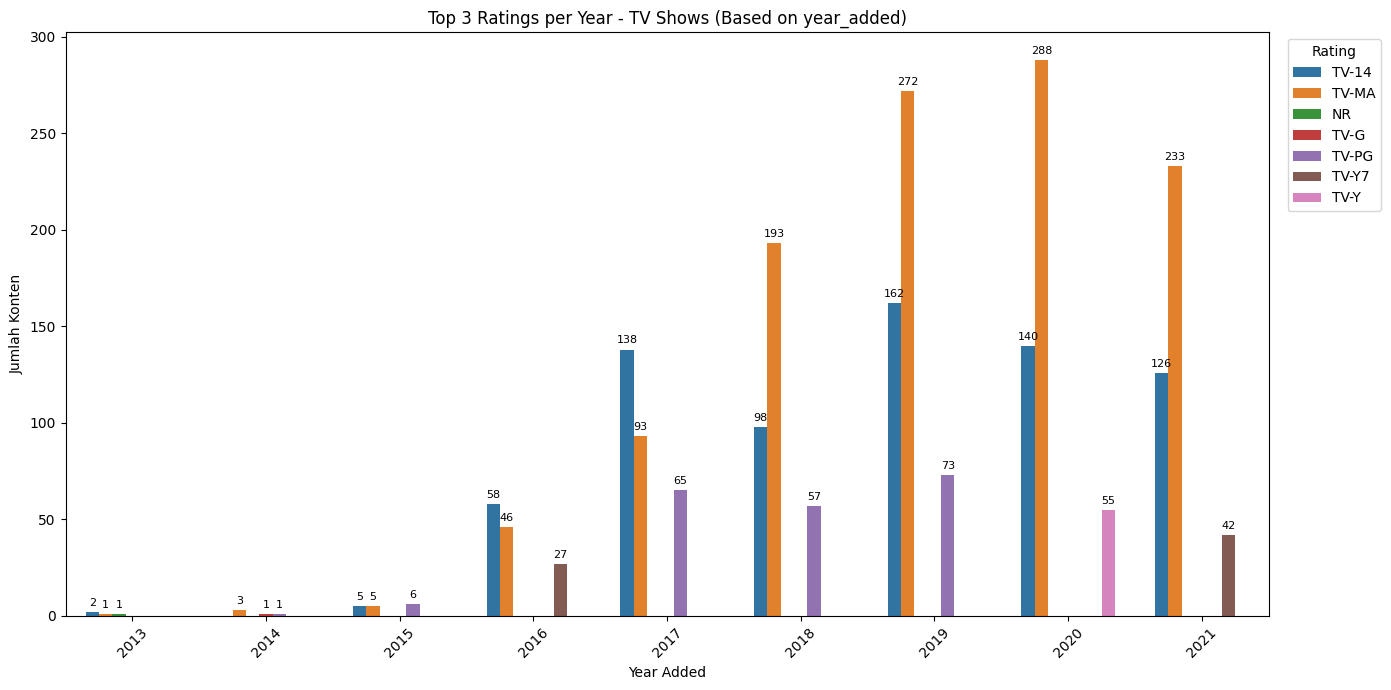

In [38]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=top_ratings_tv, x='year_added', y='count', hue='rating', dodge=True, width=0.7)



# Tambahkan label angka di atas tiap bar dengan jarak yang cukup
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=8, padding=3)

plt.title('Top 3 Ratings per Year - TV Shows (Based on year_added)')
plt.xlabel('Year Added')
plt.ylabel('Jumlah Konten')
plt.legend(title='Rating', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)

# Tambahkan jarak antar kategori (tahun) agar tidak saling menumpuk
plt.tight_layout()
plt.show()

In [39]:
import calendar
def get_top_3_genres_each_month(df):
    rows = []
    for month in sorted(df['month_added'].dropna().unique()):
        month_df = df[df['month_added'] == month]
        genres = month_df['listed_in'].dropna().str.split(',')
        all_genres = [genre.strip() for sublist in genres for genre in sublist]
        genre_counts = pd.Series(all_genres).value_counts().head(3)
        if len(genre_counts) == 3:
            for genre, count in genre_counts.items():
                rows.append({'month_added': month, 'genre': genre, 'count': count})
    return pd.DataFrame(rows)

top_genres_monthly = get_top_3_genres_each_month(net_df)
top_genres_monthly['month_name'] = top_genres_monthly['month_added'].apply(lambda x: calendar.month_name[int(x)])

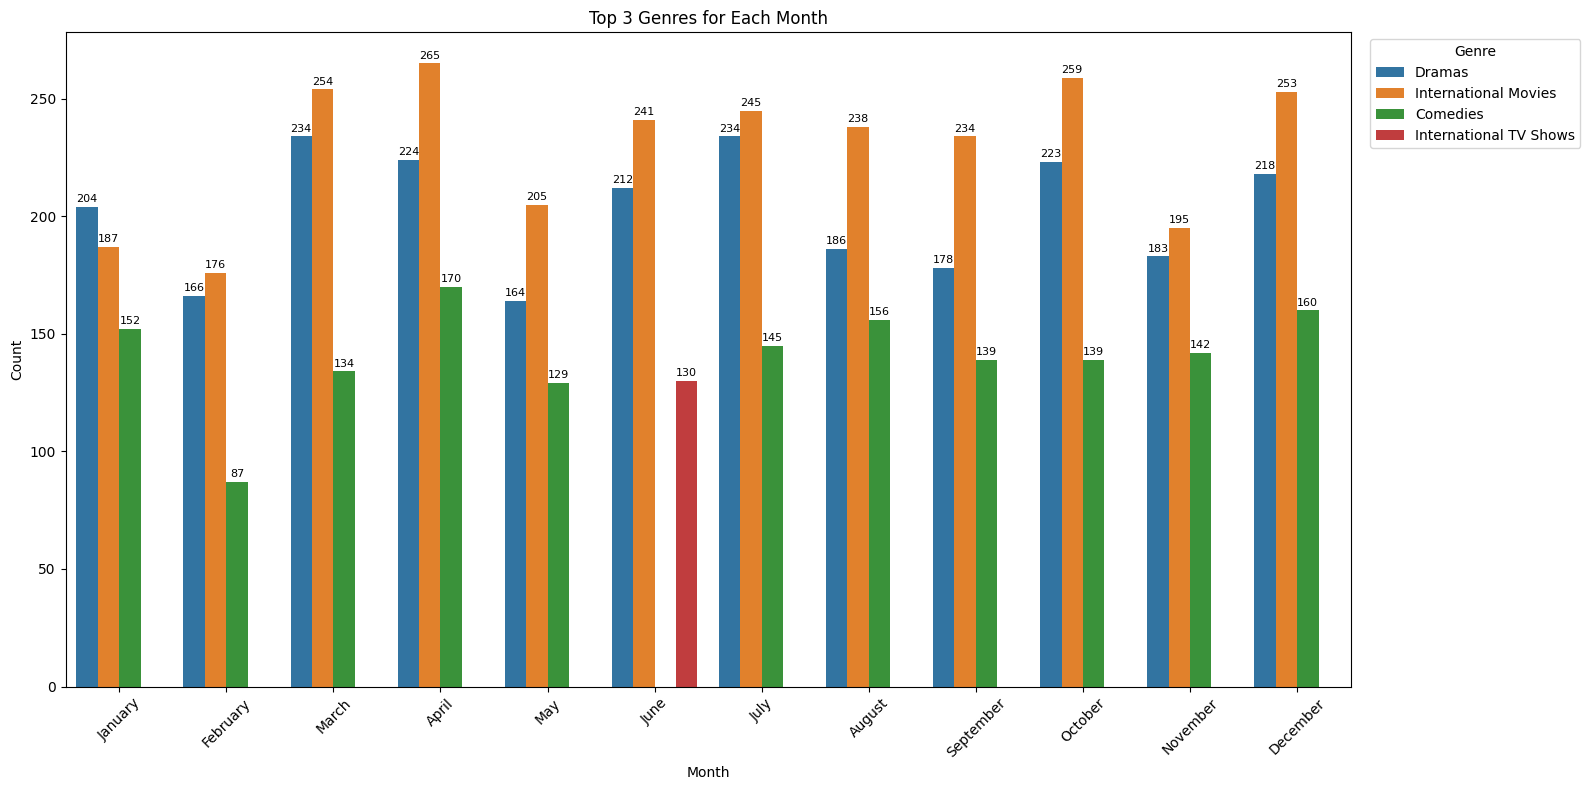

In [40]:
plt.figure(figsize=(16, 8))
ax = sns.barplot(data=top_genres_monthly, x='month_name', y='count', hue='genre', order=list(calendar.month_name)[1:])
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=8, padding=2)

plt.title('Top 3 Genres for Each Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.legend(title='Genre', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
net_df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added,day_name_added,time,time2,time3
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,September,2021,Saturday,1,1.0,NaN
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,September,2021,Friday,0,NaN,0.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9,September,2021,Friday,0,NaN,0.0
3,s4,TV Show,Jailbirds New Orleans,No Data,No Data,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9,September,2021,Friday,0,NaN,0.0
4,s5,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9,September,2021,Friday,0,NaN,0.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,9,September,2021,Friday,0,NaN,0.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,9,September,2021,Friday,0,0.0,NaN
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",9,September,2021,Friday,28,28.0,NaN
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,9,September,2021,Friday,0,NaN,0.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,9,September,2021,Friday,0,0.0,NaN


In [42]:
net_df.month_name_added.value_counts()

,count
month_name_added,
July,826
December,808
September,769
April,763
October,757
August,754
March,740
January,737
June,728


In [43]:
net_df["weather_group"] = net_df["month_added"].apply(
    lambda x: "winter" if x <= 2 or x == 12
    else "spring" if 3 <= x <= 5
    else "summer" if 6 <= x <= 8
    else "fall"
)

season_counts = net_df.groupby(by="weather_group")["show_id"].nunique().sort_values(ascending=False)

season_counts

,show_id
weather_group,
summer,2308
fall,2229
spring,2133
winter,2106


**Fall** (23 September – 20 Desember), **Winter** (21 Desember – 20 Maret), **Spring** (21 Maret – 20 Juni) dan **Summer** (21 Juni – 22 September).

Jika dilihat dari pembagian musim berdasarkan tanggal diatas,Bisa diambil kesimpulan bahwa, banyak distributor film merilis film/acara tv pada musim panas

In [44]:
net_df.rename(columns={
    'rating': 'age_ratings'
}, inplace=True)

net_df.head()


,show_id,type,title,director,cast,country,date_added,release_year,age_ratings,duration,listed_in,description,month_added,month_name_added,year_added,day_name_added,time,time2,time3,weather_group
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,September,2021,Saturday,1,1.0,NaN,fall
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,September,2021,Friday,0,NaN,0.0,fall
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9,September,2021,Friday,0,NaN,0.0,fall
3,s4,TV Show,Jailbirds New Orleans,No Data,No Data,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9,September,2021,Friday,0,NaN,0.0,fall
4,s5,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9,September,2021,Friday,0,NaN,0.0,fall


In [45]:
unique_movies = net_df[net_df['type'] == 'Movie']['title'].nunique()
unique_tv_shows = net_df[net_df['type'] == 'TV Show']['title'].nunique()


print("MOVIES =", unique_movies)
print("TV SHOWS =", unique_tv_shows)

MOVIES = 6124
TV SHOWS = 2652


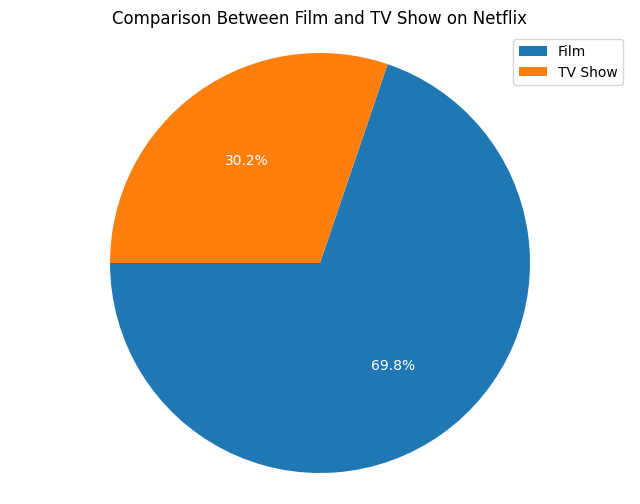

In [46]:
import matplotlib.pyplot as plt

labels = 'Film', 'TV Show'
sizes = [unique_movies, unique_tv_shows]

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=180, textprops={'color':"white"})
plt.axis('equal')


plt.title('Comparison Between Film and TV Show on Netflix')
plt.legend()


plt.show()

In [47]:
# Group by 'year_added' and 'type', then count the occurrences
type_per_year = net_df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

# Display the result
print(type_per_year)

type        Movie  TV Show
year_added                
2008            1        1
2009            2        0
2010            1        0
2011           13        0
2012            3        0
2013            6        4
2014           19        5
2015           56       26
2016          251      173
2017          835      349
2018         1236      409
2019         1424      588
2020         1284      592
2021          993      505


<Figure size 1200x800 with 0 Axes>

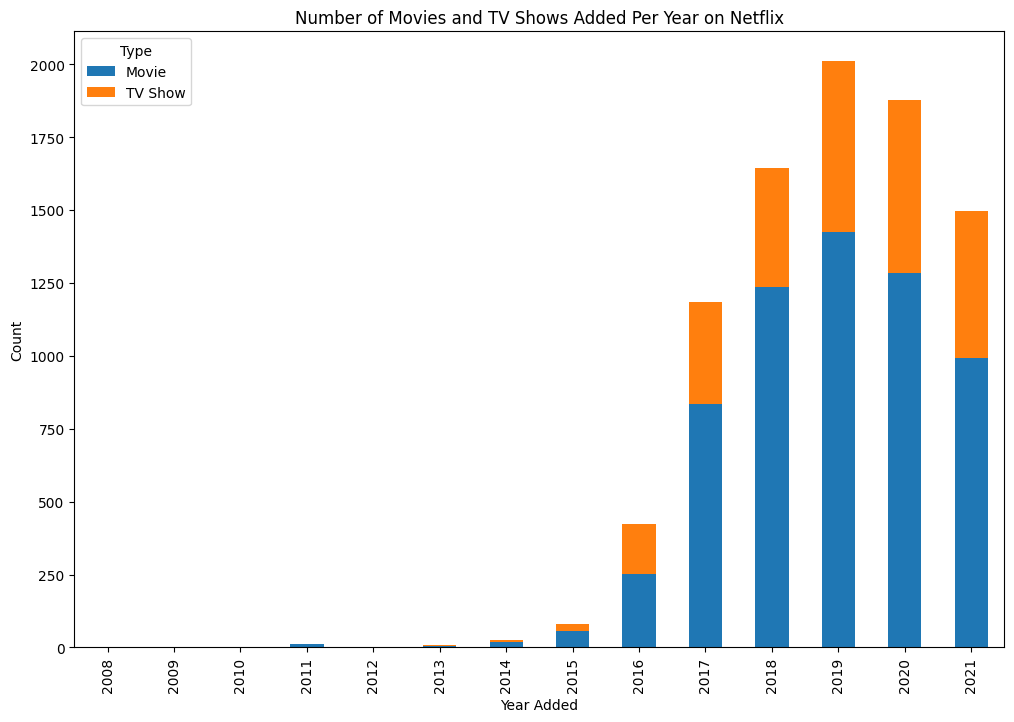

In [48]:
type_per_year = net_df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
type_per_year.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], figsize=(12, 8))

plt.xlabel('Year Added')
plt.ylabel('Count')
plt.title('Number of Movies and TV Shows Added Per Year on Netflix')
plt.legend(title="Type")

plt.show()

**Perbandingan Netflix dalam merilis suatu Film/Acara TV**

Dari diatas dapat diambil kesimpulan bahwa netflix merilis lebih banyak film dibandingkan acara tv, Netflix juga telah merilis besar-besaran pada tahun 2019 jika dibandingkan pada tahun sebelum dan sesudahnya.


**Dari berbagai film/acara tv yang dirilis pihak Netflix sering merilis pada bulan apa?**


In [49]:
tv_shows_data = net_df[net_df['type'] == 'TV Show'].copy()
movies_data = net_df[net_df['type'] == 'Movie'].copy()

movies_data['month'] = movies_data['date_added'].dt.month
tv_shows_data['month'] = tv_shows_data['date_added'].dt.month

movies_monthly_count = movies_data.groupby('month')['title'].nunique().reset_index()

tv_shows_monthly_count = tv_shows_data.groupby('month')['title'].nunique().reset_index()

best_month_movies = movies_monthly_count.sort_values('title', ascending=False).iloc[0]
best_month_tv_shows = tv_shows_monthly_count.sort_values('title', ascending=False).iloc[0]

best_month_movies, best_month_tv_shows

#bulan yang sering upload

(month      7
 title    564
 Name: 6, dtype: int64,
 month      7
 title    262
 Name: 6, dtype: int64)

Dari output diatas didapatkan bahwa film merilis paling banyak pada bulan july yang memiliki nilai sebanyak 565(Summer)

dan acara tv pada bulan desember yang memiliki nilai sebanyak 265 (Winter)

In [50]:
net_df['month'] = net_df['date_added'].dt.month
shows_monthly_rate = net_df.groupby(['age_ratings', 'month'])['title'].nunique().reset_index()

best_months_by_rating = shows_monthly_rate.sort_values(['age_ratings', 'title'], ascending=[True, False]).drop_duplicates('age_ratings')
print(best_months_by_rating)

    age_ratings  month  title
3             G      4      8
11        NC-17      1      1
25           NR     12     12
26           PG      1     38
38        PG-13      1     72
50            R      1    108
73        TV-14     12    222
80         TV-G      7     33
91        TV-MA      6    314
109       TV-PG     12     96
119        TV-Y     10     41
122       TV-Y7      1     48
134    TV-Y7-FV      2      2
138          UR      6      1


Dari output diatas didapatkan bahwa age ratings safe for watch untuk anak-anak ataupun di tonton bersama keluarga memiliki pola lebih banyak rilis pada musim liburan

In [51]:
def unnest_dataframe(df, column):
    return (
        df.drop(column, axis=1)
        .join(
            df[column].str.split(',', expand=True)
            .stack()
            .reset_index(level=1, drop=True)
            .rename(column)
        )
    )

unnested_country = unnest_dataframe(net_df, 'country')

unnested_country.head(15)

,show_id,type,title,director,cast,date_added,release_year,age_ratings,duration,listed_in,...,month_added,month_name_added,year_added,day_name_added,time,time2,time3,weather_group,month,country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,2021-09-25,2020,PG-13,90 min,Documentaries,...,9,September,2021,Saturday,1,1.0,NaN,fall,9,United States
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",...,9,September,2021,Friday,0,NaN,0.0,fall,9,South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",...,9,September,2021,Friday,0,NaN,0.0,fall,9,United States
3,s4,TV Show,Jailbirds New Orleans,No Data,No Data,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",...,9,September,2021,Friday,0,NaN,0.0,fall,9,United States
4,s5,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",...,9,September,2021,Friday,0,NaN,0.0,fall,9,India
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",...,9,September,2021,Friday,0,NaN,0.0,fall,9,United States
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",2021-09-24,2021,PG,91 min,Children & Family Movies,...,9,September,2021,Friday,0,0.0,NaN,fall,9,United States
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",...,9,September,2021,Friday,28,28.0,NaN,fall,9,United States
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",...,9,September,2021,Friday,28,28.0,NaN,fall,9,Ghana
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",...,9,September,2021,Friday,28,28.0,NaN,fall,9,Burkina Faso


In [52]:
def get_top_3_countries_each_year(df, content_type):
    rows = []
    for year in sorted(df['year_added'].dropna().unique()):
        year_df = df[df['year_added'] == year]
        countries = year_df['country'].dropna().str.split(',')
        all_countries = [country.strip() for sublist in countries for country in sublist]
        country_counts = pd.Series(all_countries).value_counts().head(3)
        if len(country_counts) == 3:
            for country, count in country_counts.items():
                rows.append({
                    'year_added': year,
                    'country': country,
                    'count': count,
                    'type': content_type
                })
    return pd.DataFrame(rows)

In [53]:
movies = net_df[net_df['type'] == 'Movie']
tv_shows = net_df[net_df['type'] == 'TV Show']

top_countries_movie = get_top_3_countries_each_year(movies, 'Movie')
top_countries_tv = get_top_3_countries_each_year(tv_shows, 'TV Show')
top_countries_combined = pd.concat([top_countries_movie, top_countries_tv])

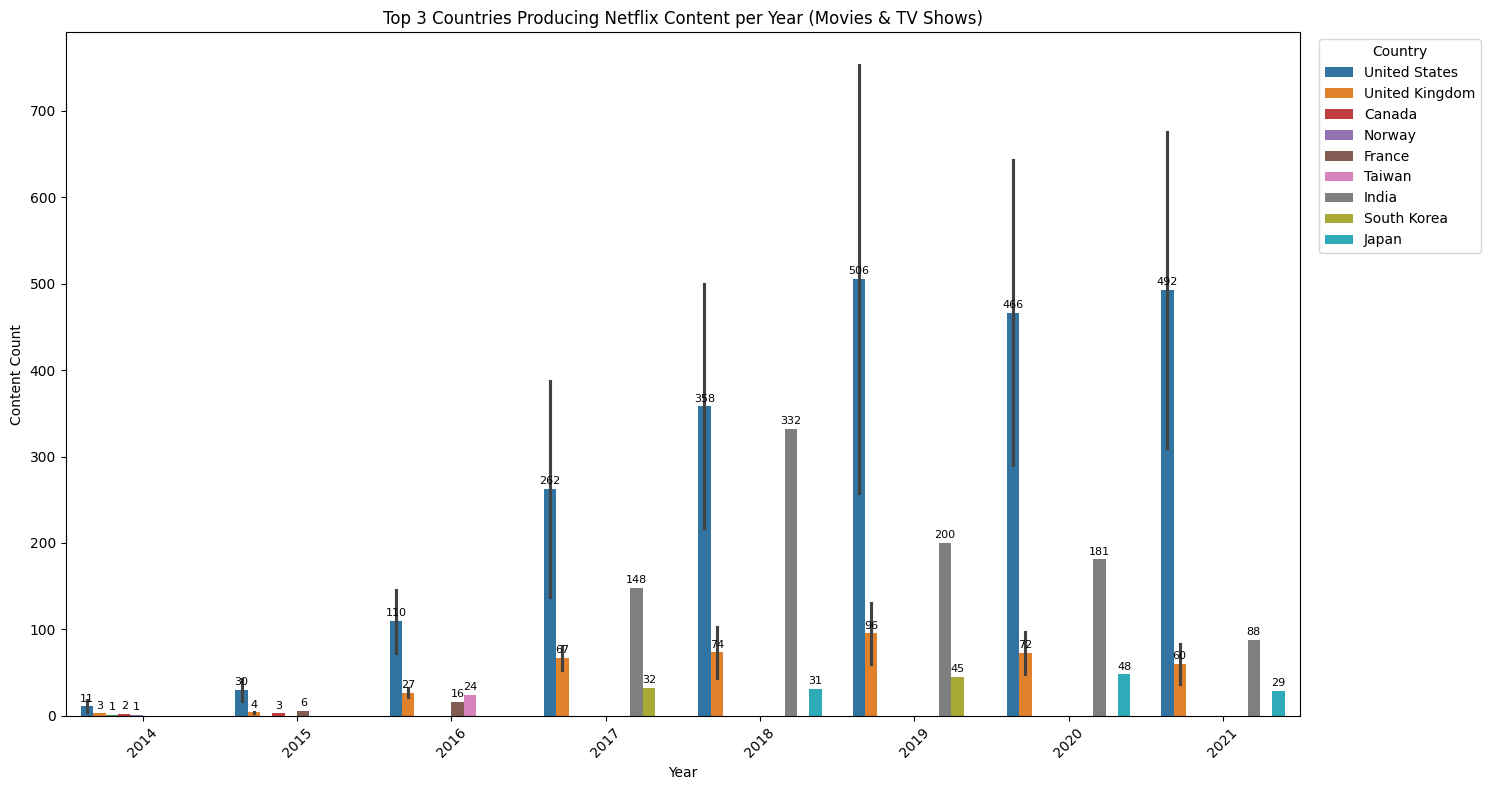

In [54]:
plt.figure(figsize=(15, 8))
ax = sns.barplot(data=top_countries_combined[top_countries_combined['year_added'] >= 2014],
                 x='year_added', y='count', hue='country')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=8, padding=2)

plt.title('Top 3 Countries Producing Netflix Content per Year (Movies & TV Shows)')
plt.xlabel('Year')
plt.ylabel('Content Count')
plt.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

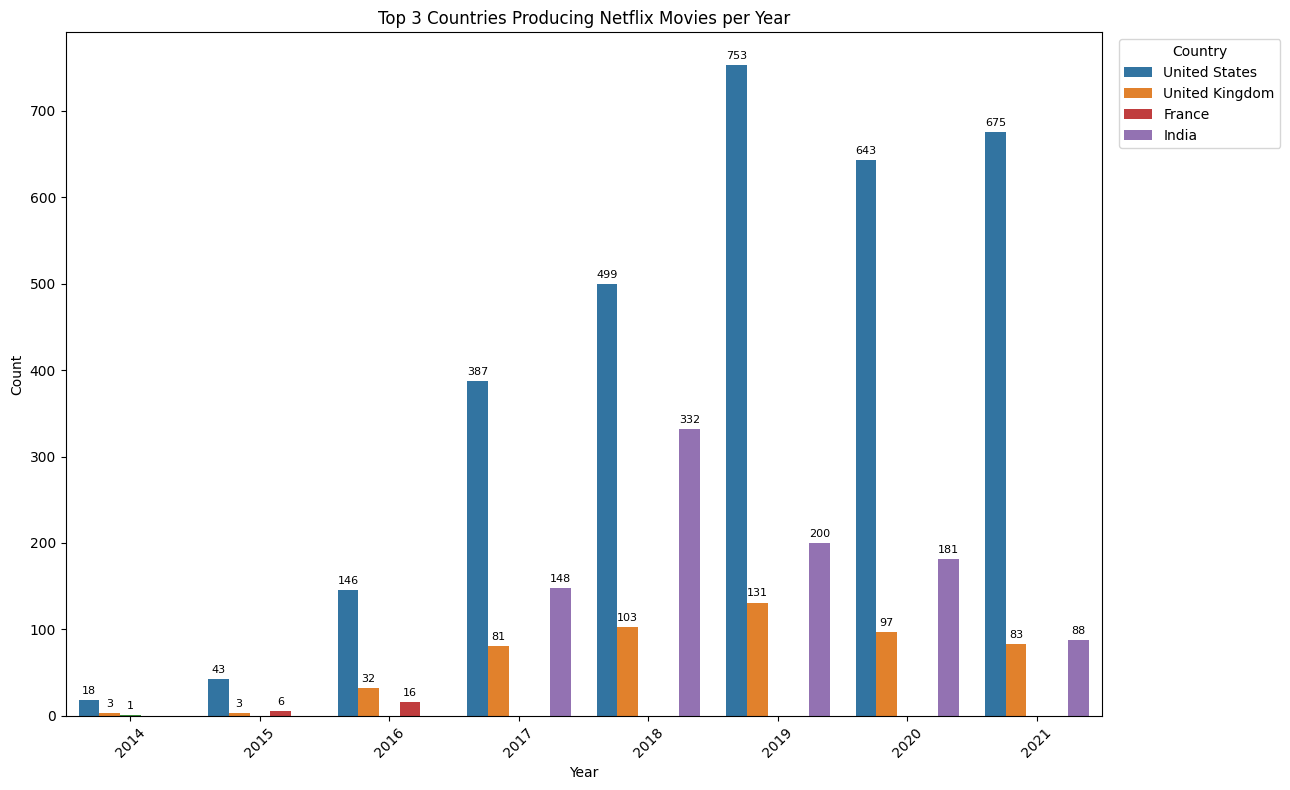

In [55]:
plt.figure(figsize=(13, 8))
ax = sns.barplot(data=top_countries_movie[top_countries_movie['year_added'] >= 2014],
                 x='year_added', y='count', hue='country')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=8, padding=3)

plt.title('Top 3 Countries Producing Netflix Movies per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

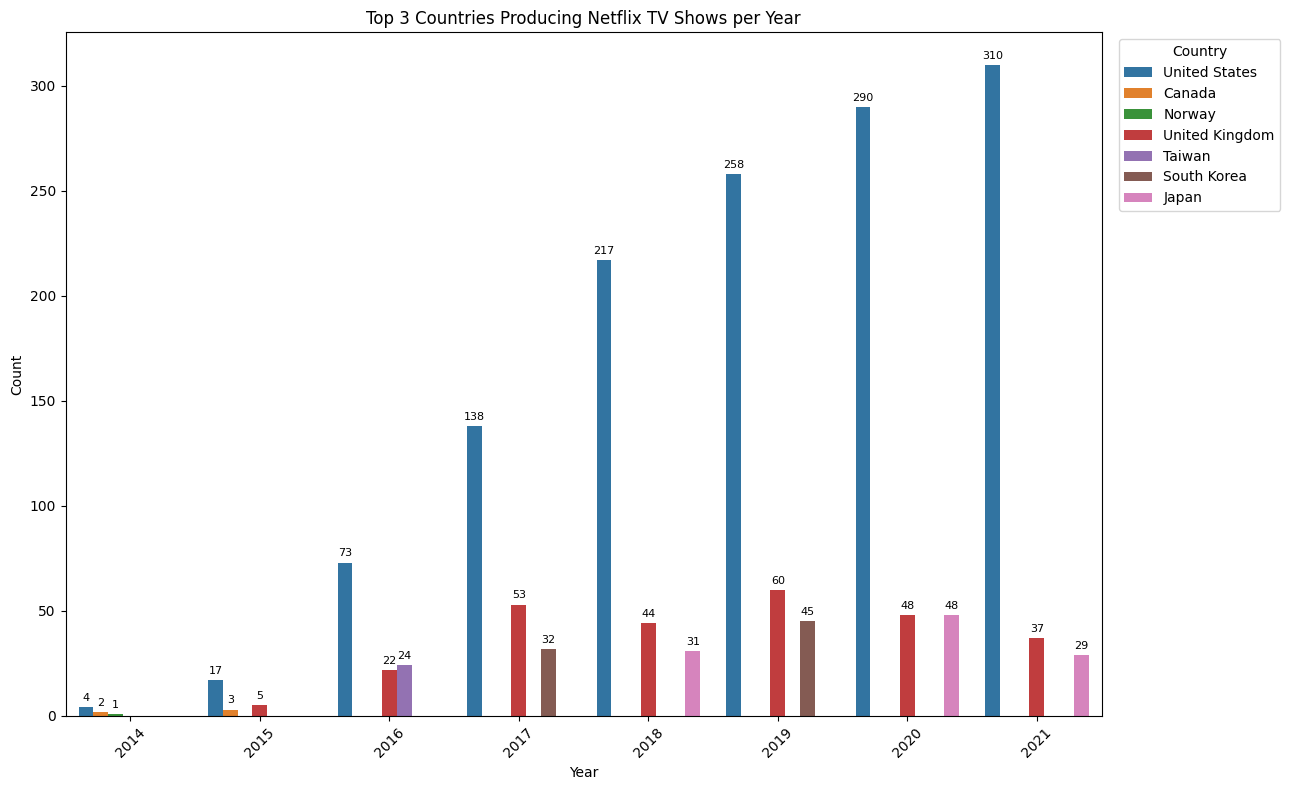

In [56]:
plt.figure(figsize=(13, 8))
ax = sns.barplot(data=top_countries_tv[top_countries_tv['year_added'] >= 2014],
                 x='year_added', y='count', hue='country')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=8, padding=3)

plt.title('Top 3 Countries Producing Netflix TV Shows per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [57]:
release_counts = net_df['release_year'].value_counts().sort_index()
top_release_years = net_df['release_year'].value_counts().head(7)
print(top_release_years)


release_year
2018    1144
2017    1029
2019    1027
2020     949
2016     900
2021     589
2015     555
Name: count, dtype: int64


<ipython-input-58-f25669da9af0>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_years.index, y=top_5_years.values, palette='viridis')


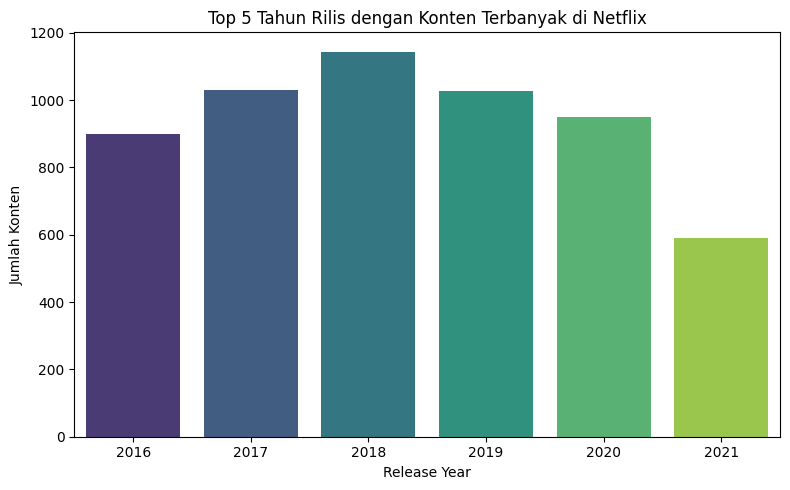

In [58]:
top_5_years = net_df['release_year'].value_counts().head(6).sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=top_5_years.index, y=top_5_years.values, palette='viridis')
plt.title('Top 5 Tahun Rilis dengan Konten Terbanyak di Netflix')
plt.xlabel('Release Year')
plt.ylabel('Jumlah Konten')
plt.tight_layout()
plt.show()


In [59]:
all_country = [country.strip() for sublist in net_df["country"].str.split(',') for country in sublist]
country_count = Counter(all_country)
country_df = pd.DataFrame(country_count.items(), columns=['country', 'Count']).sort_values(by='Count', ascending=False)

print(country_df)


            country  Count
0     United States   4499
2             India   1046
5    United Kingdom    804
15           Canada    442
12           France    392
..              ...    ...
118           Sudan      1
119          Panama      1
120          Uganda      1
121    East Germany      1
122      Montenegro      1

[123 rows x 2 columns]


In [60]:

# unnested_country['country'] = unnested_country['country'].str.strip().str.title()


# country_data = unnested_country.groupby('country').size().reset_index(name='count')


# country_data = country_data.sort_values(by='count', ascending=False)

# country_data.head(15)

In [61]:
# countrydfo = net_df['country'].value_counts()
# countrydfo

In [62]:
unnested_age_ratings = unnest_dataframe(net_df, 'age_ratings')

unnested_age_ratings.head(15)

,show_id,type,title,director,cast,country,date_added,release_year,duration,listed_in,...,month_added,month_name_added,year_added,day_name_added,time,time2,time3,weather_group,month,age_ratings
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,2021-09-25,2020,90 min,Documentaries,...,9,September,2021,Saturday,1,1.0,NaN,fall,9,PG-13
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",...,9,September,2021,Friday,0,NaN,0.0,fall,9,TV-MA
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,1 Season,"Crime TV Shows, International TV Shows, TV Act...",...,9,September,2021,Friday,0,NaN,0.0,fall,9,TV-MA
3,s4,TV Show,Jailbirds New Orleans,No Data,No Data,United States,2021-09-24,2021,1 Season,"Docuseries, Reality TV",...,9,September,2021,Friday,0,NaN,0.0,fall,9,TV-MA
4,s5,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",...,9,September,2021,Friday,0,NaN,0.0,fall,9,TV-MA
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,1 Season,"TV Dramas, TV Horror, TV Mysteries",...,9,September,2021,Friday,0,NaN,0.0,fall,9,TV-MA
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,91 min,Children & Family Movies,...,9,September,2021,Friday,0,0.0,NaN,fall,9,PG
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,125 min,"Dramas, Independent Movies, International Movies",...,9,September,2021,Friday,28,28.0,NaN,fall,9,TV-MA
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,9 Seasons,"British TV Shows, Reality TV",...,9,September,2021,Friday,0,NaN,0.0,fall,9,TV-14
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,104 min,"Comedies, Dramas",...,9,September,2021,Friday,0,0.0,NaN,fall,9,PG-13


In [63]:
unique_titles_per_age_ratings = unnested_age_ratings.groupby('age_ratings')['show_id'].nunique()

# Sorting the result in descending order
unique_titles_per_age_ratings_sorted = unique_titles_per_age_ratings.sort_values(ascending=False)

# Displaying the result
unique_titles_per_age_ratings_sorted

,show_id
age_ratings,
TV-MA,3195
TV-14,2156
TV-PG,860
R,799
PG-13,490
TV-Y7,332
TV-Y,305
PG,287
TV-G,220


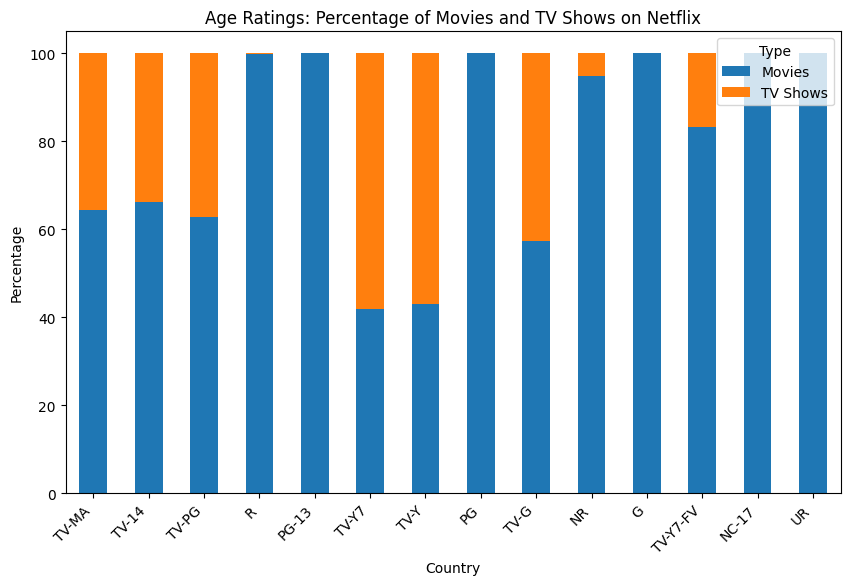

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns


filtered_age_ratings_data = unnested_age_ratings[unnested_age_ratings['age_ratings'] != 'Unknown age_ratings']

age_ratings_type_counts = filtered_age_ratings_data.groupby(['age_ratings', 'type']).size().unstack().fillna(0)

top_age_ratings = age_ratings_type_counts.sum(axis=1).sort_values(ascending=False)


top_age_ratings_data = age_ratings_type_counts.loc[top_age_ratings.index]


top_age_ratings_data_percentage = top_age_ratings_data.div(top_age_ratings_data.sum(axis=1), axis=0) * 100


plt.figure(figsize=(10, 6))
top_age_ratings_data_percentage.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Age Ratings: Percentage of Movies and TV Shows on Netflix')
plt.xlabel('Country')
plt.ylabel('Percentage')
plt.legend(title='Type', labels=['Movies', 'TV Shows'])
plt.xticks(rotation=45, ha='right')
plt.show()

In [65]:
# from sklearn.preprocessing import LabelEncoder

# # Copy of the dataframe to avoid overwriting
# encoded_df = net_df.copy()

# # Encode 'type' and 'rating' using LabelEncoder
# label_encoder = LabelEncoder()
# encoded_df['type'] = label_encoder.fit_transform(encoded_df['type'])
# encoded_df['age_ratings'] = label_encoder.fit_transform(encoded_df['age_ratings'])

# # Select numeric columns and encoded categorical columns
# selected_columns = encoded_df[['release_year', 'type', 'age_ratings']]

# # Calculate correlation matrix
# correlation = selected_columns.corr()

# # Plot heatmap
# plt.figure(figsize=(10, 8))
# sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=2)
# plt.title('Correlation Heatmap for Netflix Data (with Encoded Categorical Variables)')
# plt.show()


In [66]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [67]:
# # net_df['duration'] = net_df['duration'].str.extract('(\d+)').astype(float)

# # Separate by type
# movies_df = net_df[net_df['type'] == 'Movie'].copy()
# tvshows_df = net_df[net_df['type'] == 'TV Show'].copy()

# def run_kmeans_clustering(df, features, label):
#     # Scale the features
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(df[features])

#     # PCA for visualization (optional)
#     pca = PCA(n_components=2)
#     X_pca = pca.fit_transform(X_scaled)

#     # Silhouette analysis
#     silhouette_scores = []
#     range_n_clusters = range(2, 11)  # You can expand this range

#     for n_clusters in range_n_clusters:
#         kmeans = KMeans(n_clusters=n_clusters, random_state=42)
#         labels = kmeans.fit_predict(X_scaled)  # without PCA
#         score = silhouette_score(X_scaled, labels)
#         silhouette_scores.append(score)
#         print(f"[{label}] Clusters: {n_clusters}, Silhouette Score: {score:.4f}")

#     # Plot silhouette scores
#     plt.figure(figsize=(8, 4))
#     plt.plot(range_n_clusters, silhouette_scores, marker='o')
#     plt.title(f'Silhouette Scores for {label}')
#     plt.xlabel('Number of Clusters')
#     plt.ylabel('Silhouette Score')
#     plt.grid(True)
#     plt.show()
#     optimal_k = range_n_clusters[np.argmax(silhouette_scores)]
#     print(f"[{label}] Optimal number of clusters: {optimal_k}")

#     # Final KMeans with optimal_k
#     final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
#     clusters = final_kmeans.fit_predict(X_scaled)
#     centroids_original = scaler.inverse_transform(final_kmeans.cluster_centers_)

#     # Plot clustering
#     plt.figure(figsize=(8, 6))
#     plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
#     for i, center in enumerate(pca.transform(final_kmeans.cluster_centers_)):
#         plt.text(center[0], center[1], str(i), color='red', fontsize=12, fontweight='bold',
#                  bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3'))
#     plt.title(f'KMeans Clustering - {label}')
#     plt.xlabel('PCA 1')
#     plt.ylabel('PCA 2')
#     plt.grid(True)
#     plt.show()

gotta not comment

In [109]:
le_type = LabelEncoder()
net_df_cleaned['type_encoded'] = le_type.fit_transform(net_df_cleaned['type'])   #ubah 1 dan 0

In [234]:
# Step 1: Extract the numeric part from 'duration'
net_df['duration_num'] = net_df['duration'].str.extract('(\d+)').astype(float)

# Step 2: Convert all durations to minutes
# Assumption: 1 season ≈ 10 episodes × 45 minutes = 450 minutes
net_df['duration_in_minutes'] = net_df.apply(
    lambda row: row['duration_num'] * 450 if row['type'] == 'TV Show' else row['duration_num'],
    axis=1
)

net_df['duration_in_minutes'] = net_df['duration_in_minutes'].apply(lambda x: np.log1p(x))  # log(1 + x)

features = ['release_year', 'duration_in_minutes', 'type_encoded']
X = net_df[features]

In [235]:
# features = ['release_year', 'duration']
# # X = net_df[features]
# # #testing 2 nanti komen
#  nanti komen

In [255]:
from sklearn.preprocessing import MinMaxScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [256]:
pca = PCA(n_components=2) #2 dimensi
x_pca = pca.fit_transform(X_scaled)

For n_clusters = 2, the average silhouette score is: 0.7091592626328971
For n_clusters = 3, the average silhouette score is: 0.7488587254947546
For n_clusters = 4, the average silhouette score is: 0.6681769124535998
For n_clusters = 5, the average silhouette score is: 0.5873497183398488
For n_clusters = 6, the average silhouette score is: 0.527733073521318
For n_clusters = 7, the average silhouette score is: 0.5328960136821509
For n_clusters = 8, the average silhouette score is: 0.518918049511538
For n_clusters = 9, the average silhouette score is: 0.4166834591909213
For n_clusters = 10, the average silhouette score is: 0.4199193665603723
For n_clusters = 11, the average silhouette score is: 0.4106247821139912
For n_clusters = 12, the average silhouette score is: 0.4022662249337011
For n_clusters = 13, the average silhouette score is: 0.4004473830587341
For n_clusters = 14, the average silhouette score is: 0.4322779286928029


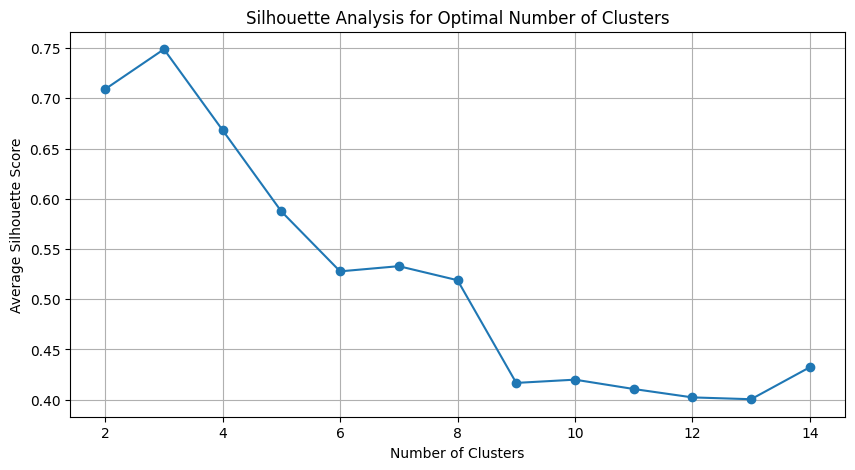

Optimal number of clusters based on Silhouette Analysis: 3


In [257]:
silhouette_scores = []
range_n_clusters = range(2, 15)  # Silhouette Score requires at least 2 clusters

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=33)
    cluster_labels = kmeans.fit_predict(x_pca)
    silhouette_avg = silhouette_score(x_pca, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {n_clusters}, the average silhouette score is: {silhouette_avg}")

# Plot Silhouette Scores
plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title('Silhouette Analysis for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Silhouette Score')
plt.grid(True)
plt.show()

# Determine the optimal number of clusters (maximum silhouette score)
optimal_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on Silhouette Analysis: {optimal_clusters}")

In [258]:
wcss = []
for i in range(1, 31):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=33)
    kmeans.fit(x_pca)
    wcss_iter = kmeans.inertia_
    wcss.append(wcss_iter)
    print(f"K = {i}, WCSS = {wcss_iter:.2f}")

K = 1, WCSS = 25472.47
K = 2, WCSS = 9340.24
K = 3, WCSS = 4152.88
K = 4, WCSS = 2891.24
K = 5, WCSS = 2522.52
K = 6, WCSS = 2051.65
K = 7, WCSS = 1710.75
K = 8, WCSS = 1413.14
K = 9, WCSS = 1249.76
K = 10, WCSS = 1108.51
K = 11, WCSS = 1047.17
K = 12, WCSS = 935.57
K = 13, WCSS = 886.58
K = 14, WCSS = 741.55
K = 15, WCSS = 687.88
K = 16, WCSS = 642.51
K = 17, WCSS = 602.48
K = 18, WCSS = 571.36
K = 19, WCSS = 536.54
K = 20, WCSS = 507.84
K = 21, WCSS = 475.99
K = 22, WCSS = 452.29
K = 23, WCSS = 431.74
K = 24, WCSS = 411.98
K = 25, WCSS = 393.53
K = 26, WCSS = 373.81
K = 27, WCSS = 354.65
K = 28, WCSS = 346.35
K = 29, WCSS = 327.91
K = 30, WCSS = 317.91


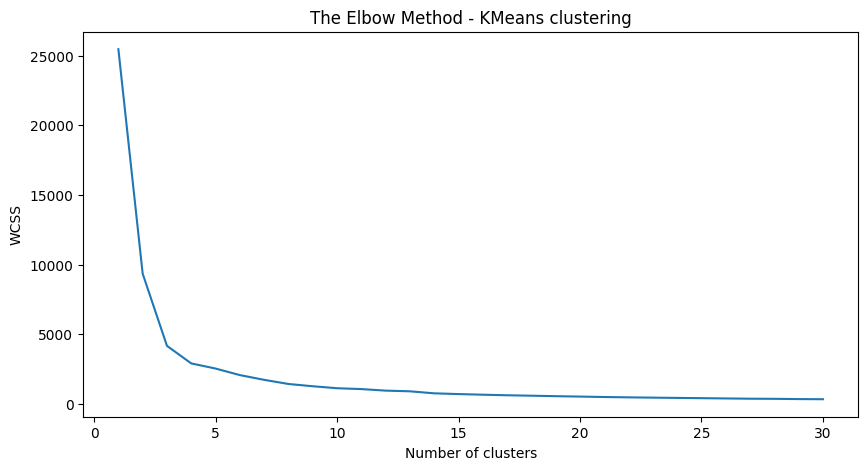

In [259]:
number_clusters = range(1, 31)
plt.figure(figsize=(10, 5))
plt.plot(number_clusters, wcss)
plt.title('The Elbow Method - KMeans clustering')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

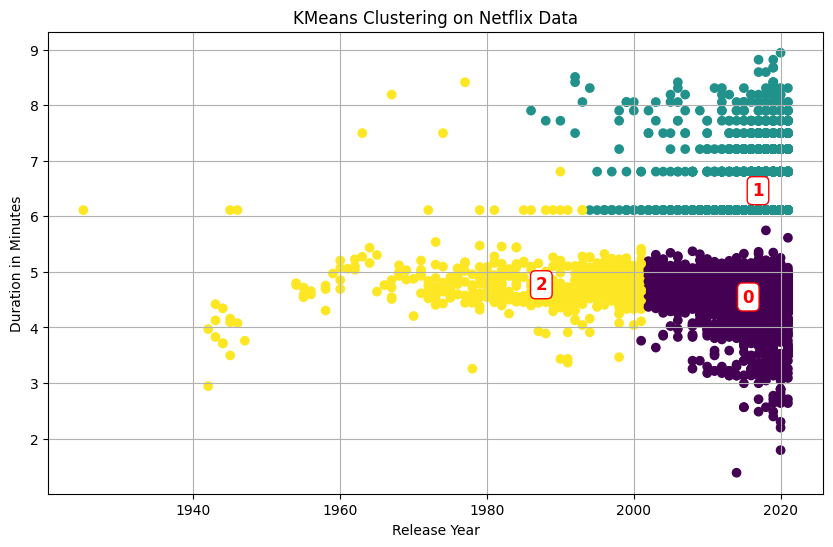

In [260]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd


# Step 3: Perform KMeans clustering
elbow_point = optimal_clusters  # You can change this to your optimal cluster count
kmeans = KMeans(n_clusters=elbow_point, init='k-means++', max_iter=300, n_init=10, random_state=33)
clusters = kmeans.fit_predict(X_scaled)

# Step 4: Add cluster labels back to DataFrame (optional, for analysis)
net_df['cluster'] = clusters

# Step 5: Inverse transform centroids to original scale
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

# Step 6: Plot using 2 main features: release_year vs duration_in_minutes
plt.figure(figsize=(10, 6))
plt.scatter(X['release_year'], X['duration_in_minutes'], c=clusters, cmap='viridis', marker='o')

# Step 7: Add cluster numbers at centroids
for i, center in enumerate(centroids_original):
    plt.text(center[0], center[1], str(i), fontsize=12, fontweight='bold', color='red',
             ha='center', va='center', bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3'))

plt.title('KMeans Clustering on Netflix Data')
plt.xlabel('Release Year')
plt.ylabel('Duration in Minutes')
plt.grid(True)
plt.show()


In [261]:
# kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=33)
# cluster_labels = kmeans.fit_predict(x_pca)

# # Visualize the clusters
# plt.figure(figsize=(10, 5))
# plt.scatter(x_pca[:, 0], x_pca[:, 1], c=cluster_labels, cmap='viridis', marker='o')
# plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='x')
# plt.title(f'KMeans Clustering with {optimal_clusters} Clusters')
# plt.xlabel('PCA Component 1')
# plt.ylabel('PCA Component 2')
# plt.show()

type      Movie  TV Show
cluster                 
0        5576.0      0.0
1           0.0   2632.0
2         548.0     20.0


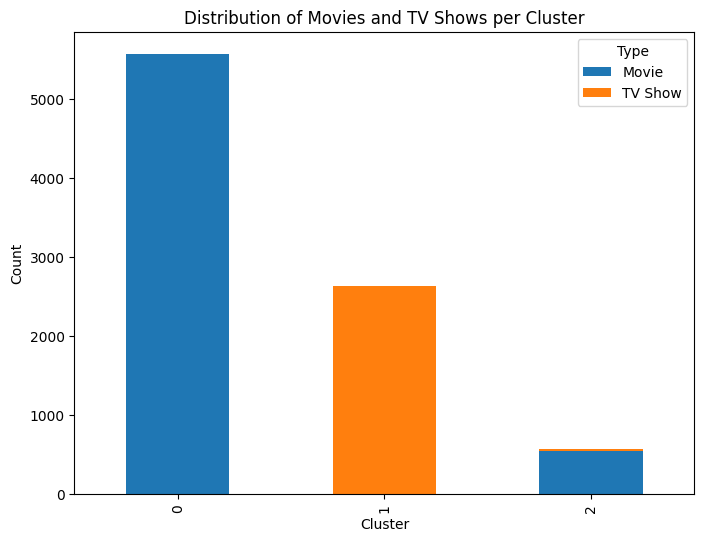

In [262]:
# Group and count by cluster and type (Movie/TV Show)
cluster_distribution = net_df.groupby(['cluster', 'type']).size().reset_index(name='count')

pivot_table = cluster_distribution.pivot_table(index='cluster', columns='type', values='count', fill_value=0)
print(pivot_table)
pivot_table.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Distribution of Movies and TV Shows per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Type')
plt.show()

In [263]:
# import seaborn as sns
# plt.figure(figsize=(8, 6))
# sns.boxplot(x='cluster', y='duration', data=net_df)
# plt.title('Distribution of Duration per Cluster')
# plt.show()

In [264]:
# Step 1: Add cluster labels to your original DataFrame
net_df_clustered = net_df.copy()
net_df_clustered['cluster'] = clusters

# Step 2: Group by cluster and type, then count
type_distribution = net_df_clustered.groupby(['cluster', 'type']).size().reset_index(name='count')

# Step 3: (Optional) Pivot for better readability
type_pivot = type_distribution.pivot(index='cluster', columns='type', values='count').fillna(0).astype(int)

# Step 4: Display the pivot table
print(type_pivot)


type     Movie  TV Show
cluster                
0         5576        0
1            0     2632
2          548       20


In [265]:
# Filter TV Shows that are in cluster 1
tv_shows_cluster_1 = net_df_clustered[(net_df_clustered['cluster'] == 2) & (net_df_clustered['type'] == 'TV Show') & (net_df_clustered['duration_in_minutes'] <= 30)]

# Display the result
print(tv_shows_cluster_1)


     show_id     type                                 title  \
813     s814  TV Show  The Adventures of Sonic the Hedgehog   
1331   s1332  TV Show   Five Came Back: The Reference Films   
2301   s2302  TV Show                     Supermarket Sweep   
4250   s4251  TV Show     Pioneers: First Women Filmmakers*   
4550   s4551  TV Show      Monty Python's Fliegender Zirkus   
4551   s4552  TV Show          Monty Python's Flying Circus   
5299   s5300  TV Show                             High Risk   
6347   s6348  TV Show        Bob Ross: Beauty Is Everywhere   
6549   s6550  TV Show                            Dad's Army   
6674   s6675  TV Show                              El Chavo   
7175   s7176  TV Show              Ken Burns: The Civil War   
7588   s7589  TV Show                         Ninja Hattori   
7743   s7744  TV Show   Pioneers of African-American Cinema   
7878   s7879  TV Show                              Robotech   
7993   s7994  TV Show                            Shaka 

In [266]:
# Average duration for cluster 0
avg_duration_cluster_0 = net_df_clustered[net_df_clustered['cluster'] == 0]['duration_in_minutes'].mean()
avg_duration_cluster_1 = net_df_clustered[net_df_clustered['cluster'] == 1]['duration_in_minutes'].mean()
avg_duration_cluster_2 = net_df_clustered[net_df_clustered['cluster'] == 2]['duration_in_minutes'].mean()
max_duration_cluster_0 = net_df_clustered[net_df_clustered['cluster'] == 0]['duration_in_minutes'].max()
print(f"Average duration for cluster 0: {avg_duration_cluster_0:.2f} minutes")
print(f"Average duration for cluster 1: {avg_duration_cluster_1:.2f} minutes")
print(f"Average duration for cluster 2: {avg_duration_cluster_2:.2f} minutes")
print(f"Average duration for cluster 0: {max_duration_cluster_0:.2f} minutes")

Average duration for cluster 0: 4.55 minutes
Average duration for cluster 1: 6.46 minutes
Average duration for cluster 2: 4.77 minutes
Average duration for cluster 0: 5.75 minutes


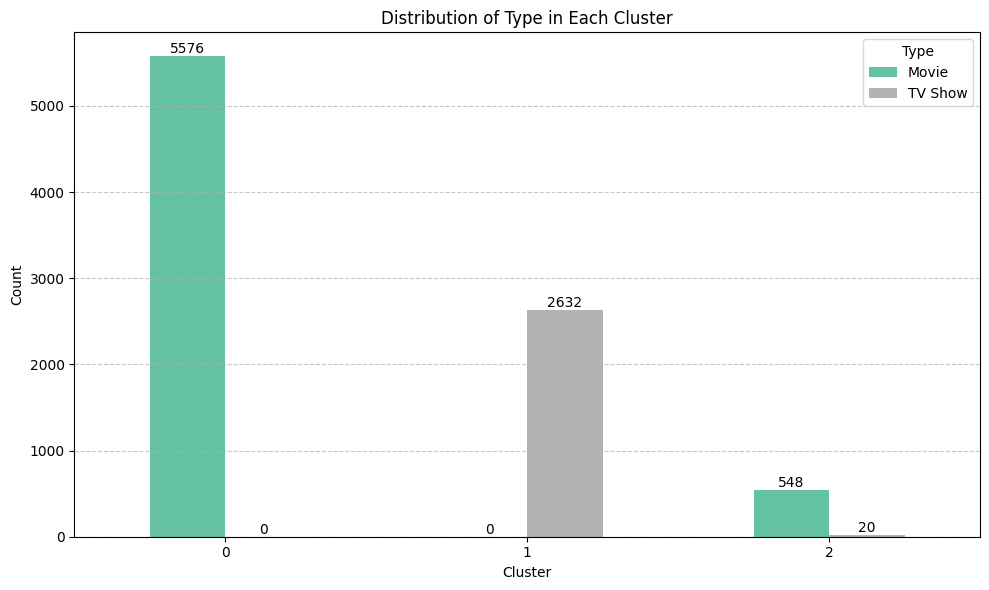

In [267]:
import matplotlib.pyplot as plt

# Step 1: Use the pivot table from before
ax = type_pivot.plot(kind='bar', figsize=(10, 6), colormap='Set2')

for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

# Step 2: Styling
plt.title('Distribution of Type in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [268]:
# range_n_clusters = range(2, 31)
# silhouette_avg = []
# for num_clusters in range_n_clusters:
#     kmeans = KMeans(n_clusters=num_clusters, init='k-means++', random_state=33)
#     kmeans.fit(x_pca)
#     cluster_labels = kmeans.labels_
#     silhouette_avg.append(silhouette_score(x_pca, cluster_labels))

In [269]:
# plt.figure(figsize=(10, 5))
# plt.plot(range_n_clusters, silhouette_avg)
# plt.xlabel('Values of K')
# plt.ylabel('Silhouette score')
# plt.title('Silhouette analysis for Optimal k - KMeans clustering')
# plt.show()

In [270]:
# kmeans = KMeans(n_clusters=3, init='k-means++', random_state=33)
# kmeans.fit(x_pca)

In [271]:
kmeans_distortion = kmeans.inertia_
kmeans_silhouette_score = silhouette_score(x_pca, kmeans.labels_)
print("Distortion (WCSS):", kmeans_distortion)
print("Silhouette Score:", kmeans_silhouette_score)

Distortion (WCSS): 4965.631533235512
Silhouette Score: 0.7488354485835578


In [272]:
# net_df['kmeans_cluster'] = kmeans.labels_

In [273]:
# import matplotlib.pyplot as plt
# import pandas as pd

# # Create a crosstab of cluster vs type
# cluster_type_dist = pd.crosstab(net_df['kmeans_cluster'],net_df['type'])

# # Plot as a grouped bar chart
# cluster_type_dist.plot(kind='bar', figsize=(10, 6), colormap='Set2')

# plt.title('Distribution of Type in Each Cluster')
# plt.xlabel('Cluster')
# plt.ylabel('Number of Items')
# plt.xticks(rotation=0)
# plt.legend(title='Type')
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()
